# Proyecto 2: Detección de lavado de dinero

Sistema de dos etapas sobre la secuencia de transacciones de cada emisor (remitente). La Etapa A aprende cómo se ve el comportamiento normal con un autoencoder, sin etiquetas. La Etapa B clasifica casos de lavado etiquetados, partiendo de lo aprendido en la Etapa A.

| Componente | Secciones |
|---|---|
| 1. Ingeniería de datos y secuencias | 1–13 |
| 2. Sistema en dos etapas | 14 (Etapa A), 15 (Etapa B y ablación) |
| 3. Análisis e interpretabilidad | 16 |

## 0. Setup

In [1]:
import os, sys, gc, glob, json, math, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (10, 4)

# Find data if working in Colab or Kaggle
IN_COLAB = "google.colab" in sys.modules
IN_KAGGLE = os.path.isdir("/kaggle/input")
OUT_DIR = ("/kaggle/working/aml_outputs" if IN_KAGGLE else "/content/aml_outputs" if IN_COLAB else "./aml_outputs")
os.makedirs(OUT_DIR, exist_ok=True)
print("Colab:", IN_COLAB, "| Kaggle:", IN_KAGGLE, "| outputs ->", OUT_DIR)

T0 = time.time()
def elapsed():
    """Minutes since the notebook started, for progress prints."""
    return f"[{(time.time() - T0) / 60:.1f} min]"


Colab: False | Kaggle: False | outputs -> ./aml_outputs


**Dataset.** IBM AML *HI-Small*. Se usa como dataset principal en lugar de PaySim, este simula bancos, personas y empresas con lavado inyectado en topologías conocidas y emisores con historia repetida, que es lo que necesita un modelo de secuencias. Visitando diferentes fuentes se encontró que los patrones y secuencias en este dataset son bastante más detallados. Se usa la variante HI-Small completa, sin submuestreo adicional, porque ya es suficientemente grande para entrenar (más de cinco millones de transacciones y 3,376 emisores que lavan en algún momento).

In [2]:
DATASET = "ealtman2019/ibm-transactions-for-anti-money-laundering-aml"
FILES = ["HI-Small_Trans.csv", "HI-Small_Patterns.txt"]

def find_under(root, name):
    hits = glob.glob(os.path.join(root, "**", name), recursive=True)
    return hits[0] if hits else None

paths = {}
if os.environ.get("AML_DATA_DIR"):                 # local copy
    for f in FILES:
        paths[f] = find_under(os.environ["AML_DATA_DIR"], f)
elif IN_KAGGLE:                                    # dataset attached as input
    for f in FILES:
        paths[f] = find_under("/kaggle/input", f)
else:                                              # Colab: download single files only
    try:
        import kagglehub
    except ImportError:
        raise RuntimeError("Run: !pip install -q kagglehub")
    for f in FILES:
        try:
            p = kagglehub.dataset_download(DATASET, path=f)      # single file, not the whole dataset
        except TypeError:
            raise RuntimeError("Old kagglehub without single-file download. Run: !pip install -q -U kagglehub, "
                               "then Runtime -> Restart session")
        paths[f] = p if os.path.isfile(p) else find_under(p, f)

for f, p in paths.items():
    assert p and os.path.isfile(p), f"Could not find {f}"
    print(f"{f}: {os.path.getsize(p) / 1e6:,.0f} MB")
TRANS_PATH, PATTERNS_PATH = paths[FILES[0]], paths[FILES[1]]

HI-Small_Trans.csv: 476 MB
HI-Small_Patterns.txt: 0 MB


# Componente 1: Ingeniería de datos y secuencias

## 1. Primer vistazo

In [3]:

# Hay 2 columnas con el nombre account, se soluciona cargando nombres y tipos de columna
# de antemano antes de leer el dataset
COLS = ["ts", "from_bank", "from_acct", "to_bank", "to_acct", "amt_received", "recv_currency",
        "amt_paid", "pay_currency", "pay_format", "is_laundering"]
DTYPES = {"ts": "string", "from_bank": "int64", "from_acct": "string", "to_bank": "int64",
          "to_acct": "string", "amt_received": "float64", "recv_currency": "category",
          "amt_paid": "float64", "pay_currency": "category", "pay_format": "category",
          "is_laundering": "int8"}

with open(TRANS_PATH) as f:                      # raw header: note the two columns named "Account"
    for _ in range(3):
        print(f.readline().rstrip())

df = pd.read_csv(TRANS_PATH, names=COLS, header=0, dtype=DTYPES)
df["ts"] = pd.to_datetime(df["ts"], format="%Y/%m/%d %H:%M")
df = df.sort_values("ts", kind="stable").reset_index(drop=True)
df["tx_id"] = np.arange(len(df), dtype=np.int64)

n_pos = int(df.is_laundering.sum())
print(f"\nRows: {len(df):,} | columns with nulls: {df.columns[df.isna().any()].tolist() or 'none'}")
print(f"Time range: {df.ts.min()} -> {df.ts.max()}")
print(f"Laundering transactions: {n_pos:,} ({n_pos / len(df):.4%}), about 1 in {len(df) // n_pos:,} {elapsed()}")
display(df.head())

Timestamp,From Bank,Account,To Bank,Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
2022/09/01 00:20,010,8000EBD30,010,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
2022/09/01 00:20,03208,8000F4580,001,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0

Rows: 5,078,345 | columns with nulls: none
Time range: 2022-09-01 00:00:00 -> 2022-09-18 16:18:00
Laundering transactions: 5,177 (0.1019%), about 1 in 980 [0.1 min]


,ts,from_bank,from_acct,to_bank,to_acct,amt_received,recv_currency,amt_paid,pay_currency,pay_format,is_laundering,tx_id
0,2022-09-01,3209,8000F4670,3209,8000F4670,"14,675.5700",US Dollar,"14,675.5700",US Dollar,Reinvestment,0,0
1,2022-09-01,1420,8005DFEB0,1420,8005DFEB0,897.3700,US Dollar,897.3700,US Dollar,Reinvestment,0,1
2,2022-09-01,10,8000F6850,10,8000F6850,"99,986.9400",US Dollar,"99,986.9400",US Dollar,Reinvestment,0,2
3,2022-09-01,12,8001167D0,12,8001167D0,16.0800,US Dollar,16.0800,US Dollar,Reinvestment,0,3
4,2022-09-01,1,8001364A0,1,8001364A0,10.3000,US Dollar,10.3000,US Dollar,Reinvestment,0,4


**Hallazgos**

- 5,078,345 transacciones en ~18 días de Septiembre de 2022.
- No hay valores nulos.
- 5,177 son lavado, **0.10% o ~1 de cada 980**.

**Decisiones**

Accuracy no sirve con 0.10% de positivos, hay que utilizar diferentes métricas para evaluar los modelos

## 2. Identificación de cuentas

In [4]:
same_id_diff_bank = (df.groupby("from_acct", observed=True)["from_bank"].nunique() > 1).sum()
print(f"Account ids that appear under more than one bank: {same_id_diff_bank:,}")
print(f"Transactions where sender == receiver (same bank and account): "
      f"{((df.from_bank == df.to_bank) & (df.from_acct == df.to_acct)).mean():.2%}")

Account ids that appear under more than one bank: 4
Transactions where sender == receiver (same bank and account): 11.64%


**Hallazgos**

- El id de cuenta solo tiene sentido junto con su banco (4 id's aparecen con bancos distintos).
- ~11.6% de las transacciones van de una cuenta a sí misma.

**Decisiones**

Una cuenta se identifica por `bank_account`. Codificamos cuentas como enteros para ahorrar memoria y guardamos una tabla de nombres para el MVP. Las auto-transferencias se mantienen y se marcan con un feature en vez de eliminarse.

In [5]:
n = len(df)
sender_str = df["from_bank"].astype(str) + "_" + df["from_acct"].astype(str)
receiver_str = df["to_bank"].astype(str) + "_" + df["to_acct"].astype(str)
codes, uniques = pd.factorize(pd.concat([sender_str, receiver_str], ignore_index=True))
ACCOUNT_NAMES = np.asarray(uniques, dtype=object)
df["sender"] = codes[:n].astype(np.int32)
df["receiver"] = codes[n:].astype(np.int32)
df["is_self"] = (df["sender"] == df["receiver"]).astype(np.float32)
df["same_bank"] = (df["from_bank"] == df["to_bank"]).astype(np.float32)
del sender_str, receiver_str, codes, uniques
print(f"Accounts: {len(ACCOUNT_NAMES):,} | senders: {df.sender.nunique():,} {elapsed()}")

Accounts: 515,088 | senders: 496,999 [0.1 min]


## 3. Monedas y montos

In [6]:
display(df["pay_currency"].value_counts().to_frame("transactions"))
cross = df["pay_currency"].astype(str).to_numpy() != df["recv_currency"].astype(str).to_numpy()
print(f"Cross-currency transactions: {cross.mean():.2%}")

,transactions
pay_currency,
US Dollar,1895172
Euro,1168297
Swiss Franc,234860
Yuan,213752
Shekel,192184
Rupee,190202
UK Pound,180738
Yen,155209
Ruble,155178


Cross-currency transactions: 1.42%


**Hallazgos**

- 15 monedas; Dólar (1.9M) y Euro (1.2M) dominan, y Bitcoin es una de ellas.
- Solo el 1.42% de las transacciones cambian de moneda, pero esas filas revelan el tipo de cambio que usa el
  simulador (monto recibido / monto pagado).
- Los montos crudos no son comparables entre monedas.

**Decisiones**

Convertimos todo a USD usando la tasa mediana implícita en las transacciones cross-currency pagadas en cada moneda y recibidas en USD. Las filas sin tasa se descartarían (en la práctica no hay ninguna). Se guarda una bandera de cross-currency como feature.

In [7]:
USD = "US Dollar"
pay_cur = df["pay_currency"].astype(str).to_numpy()
recv_cur = df["recv_currency"].astype(str).to_numpy()
to_usd = cross & (recv_cur == USD)
rates = (pd.Series(df["amt_received"].to_numpy()[to_usd] / df["amt_paid"].to_numpy()[to_usd])
           .groupby(pay_cur[to_usd]).median())
rates[USD] = 1.0
missing = sorted(set(np.unique(pay_cur)) - set(rates.index))
print("Currencies without a USD rate (rows dropped):", missing or "none")
df["amt_usd"] = df["amt_paid"].to_numpy() * pd.Series(pay_cur).map(rates).to_numpy()
df["is_cross_currency"] = cross.astype(np.float32)
df = df[df["amt_usd"].notna()].reset_index(drop=True)
display(rates.sort_values().to_frame("to_usd"))
del pay_cur, recv_cur, cross, to_usd

Currencies without a USD rate (rows dropped): none


,to_usd
Yen,0.0095
Ruble,0.0129
Rupee,0.0136
Mexican Peso,0.0473
Yuan,0.1493
Brazil Real,0.1771
Saudi Riyal,0.2666
Shekel,0.2961
Australian Dollar,0.7078
Canadian Dollar,0.7580


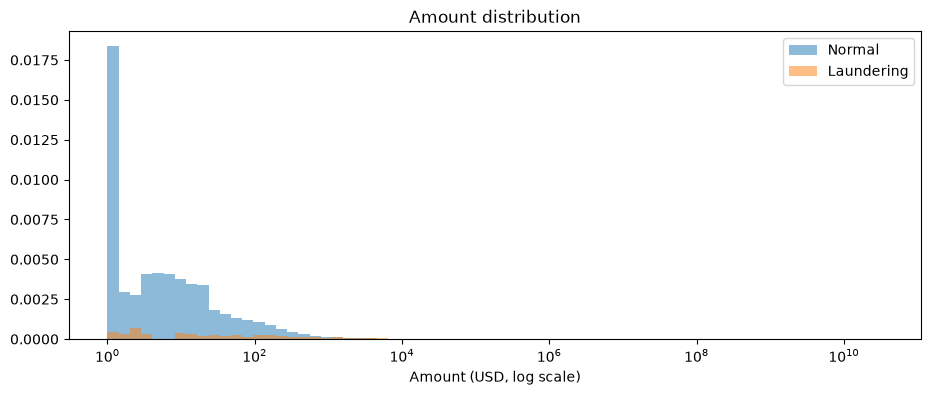

,count,mean,std,min,25%,50%,75%,99%,max
is_laundering,,,,,,,,,
0,"5,073,168.0000","346,030.8567","23,233,414.7798",0.0001,158.0000,891.0500,"5,273.8331","3,099,715.3200","26,558,613,301.7214"
1,"5,177.0000","5,169,483.6401","231,331,481.7001",0.3867,"2,160.5600","5,878.8063","13,758.5029","15,793,198.1262","16,297,043,812.7494"


In [8]:
x_all = df["amt_usd"].clip(lower=1)
bins = np.logspace(0, np.log10(x_all.max()) + 0.1, 70)
fig, ax = plt.subplots(figsize=(11, 4))
for label, name in [(0, "Normal"), (1, "Laundering")]:
    ax.hist(df.loc[df.is_laundering == label, "amt_usd"].clip(lower=1), bins=bins, density=True, alpha=0.5, label=name)
ax.set_xscale("log"); ax.set_xlabel("Amount (USD, log scale)"); ax.set_title("Amount distribution"); ax.legend()
plt.show()
display(df.groupby("is_laundering")["amt_usd"].describe(percentiles=[.25, .5, .75, .99]))

**Hallazgos**

- Los montos abarcan ~14 órdenes de magnitud (de 0.0001 a 2.6×10¹⁰ USD).
- Los montos de lavado suelen ser mayores (mediana ≈ 5,879 USD contra 891 USD), pero se traslapan mucho: el monto solo no separa las clases.

**Decisiones**

Usamos `log(1 + monto)` para que los valores extremos no dominen, más el monto **relativo al monto típico del propio emisor** en la secuencia ("inusualmente grande para esta persona").

## 4. Tiempo

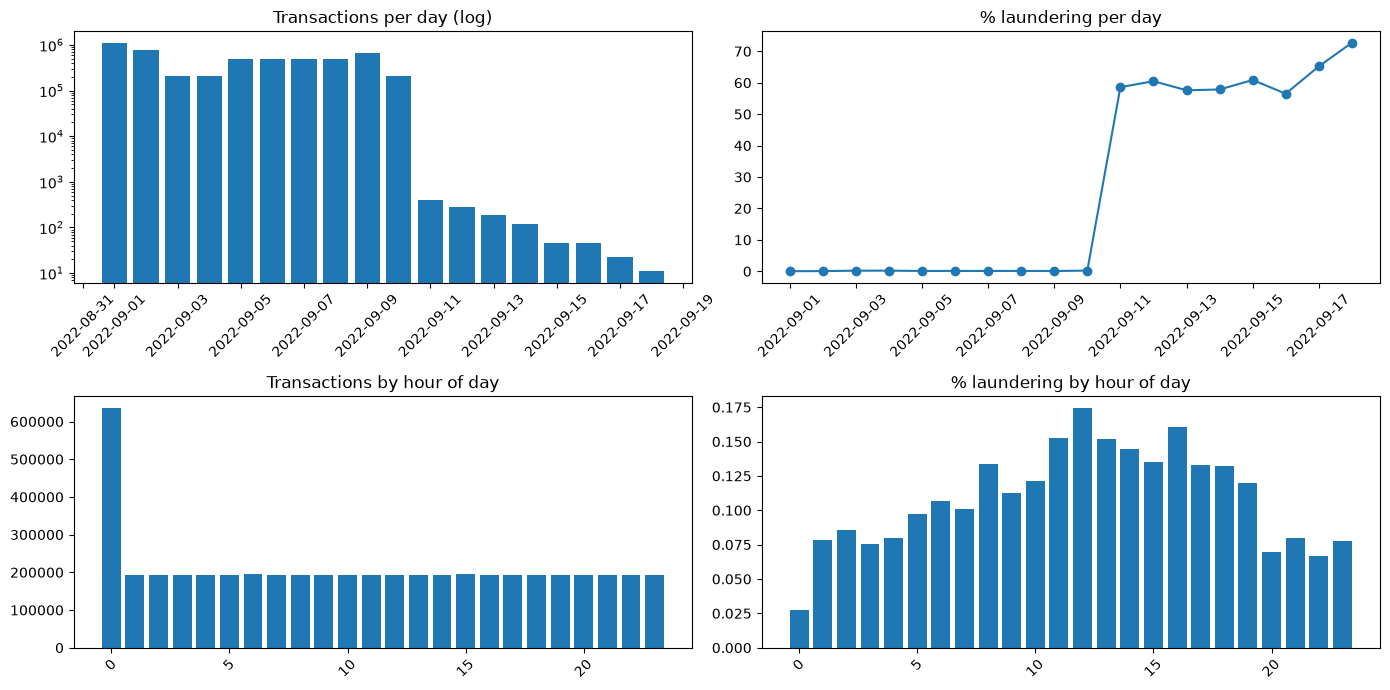

,size,mean
ts,,
2022-09-01,1114921,0.0003
2022-09-02,754449,0.0005
2022-09-03,207382,0.0019
2022-09-04,207430,0.0020
2022-09-05,482650,0.0010
2022-09-06,482089,0.0011
2022-09-07,482751,0.0010
2022-09-08,482773,0.0011
2022-09-09,654467,0.0008


In [9]:
daily = df.set_index("ts").resample("D")["is_laundering"].agg(["size", "mean"])
hourly = df.groupby(df.ts.dt.hour)["is_laundering"].agg(["size", "mean"])
fig, ax = plt.subplots(2, 2, figsize=(14, 7))
ax[0, 0].bar(daily.index, daily["size"]); ax[0, 0].set_yscale("log"); ax[0, 0].set_title("Transactions per day (log)")
ax[0, 1].plot(daily.index, daily["mean"] * 100, marker="o"); ax[0, 1].set_title("% laundering per day")
ax[1, 0].bar(hourly.index, hourly["size"]); ax[1, 0].set_title("Transactions by hour of day")
ax[1, 1].bar(hourly.index, hourly["mean"] * 100); ax[1, 1].set_title("% laundering by hour of day")
for a in ax.flat:
    a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()
display(daily)

**Hallazgos**

- La actividad normal se detiene después del 2022-09-10. Del 09-11 al 09-18 hay ~1,100 transacciones, ~60% de lavado: el simulador sigue corriendo intentos de lavado ya iniciados.
- Los volúmenes por día y por hora saltan entre niveles fijos (1.1M el día 1, ~200k otros días; 634k en la hora 0). Es el scheduling del simulador, no comportamiento.

Seguimiento: cuánto lavado vive solo en la cola, y qué es el pico de medianoche.

In [10]:
TAIL_START = "2022-09-11"
tail = df["ts"] >= pd.Timestamp(TAIL_START)
laund = df["is_laundering"] == 1
pre_senders = set(df.loc[~tail & laund, "sender"].unique())
tail_senders = set(df.loc[tail & laund, "sender"].unique())
print(f"Tail transactions: {int(tail.sum()):,} ({df.loc[tail, 'is_laundering'].mean():.1%} laundering)")
print(f"Laundering tx in tail: {int((tail & laund).sum()):,} of {int(laund.sum()):,} "
      f"({(tail & laund).sum() / laund.sum():.1%})")
print(f"Positive senders whose laundering happens ONLY in the tail: {len(tail_senders - pre_senders):,} "
      f"of {len(pre_senders | tail_senders):,}")

hour = df["ts"].dt.hour
at_midnight = (hour == 0) & (df["ts"].dt.minute == 0)
print(f"\nHour-0 transactions: {int((hour == 0).sum()):,}, of which exactly 00:00: {at_midnight[hour == 0].mean():.1%}")
print(f"Laundering rate at 00:00: {df.loc[at_midnight, 'is_laundering'].mean():.4%} | "
      f"rest of the day: {df.loc[~at_midnight, 'is_laundering'].mean():.4%}")
display(pd.DataFrame({"share at 00:00": df.loc[at_midnight, "pay_format"].value_counts(normalize=True),
                      "share overall": df["pay_format"].value_counts(normalize=True)}))
del tail, laund, hour, at_midnight

Tail transactions: 1,108 (59.1% laundering)
Laundering tx in tail: 655 of 5,177 (12.7%)
Positive senders whose laundering happens ONLY in the tail: 340 of 3,376

Hour-0 transactions: 634,726, of which exactly 00:00: 2.8%
Laundering rate at 00:00: 0.0166% | rest of the day: 0.1022%


,share at 00:00,share overall
pay_format,,
ACH,0.0507,0.1183
Bitcoin,0.0296,0.0288
Cash,0.0329,0.0967
Cheque,0.1193,0.3671
Credit Card,0.3238,0.2606
Reinvestment,0.4282,0.0947
Wire,0.0156,0.0338


**Hallazgos**

- La cola tiene 1,108 transacciones, 59% de lavado. 655 transacciones (12.7% del lavado total).
- 340 de los 3,376 emisores positivos (10%) lavan solo en la cola.
- El pico de medianoche no es un batch: solo 2.8% de la hora 0 está marcada exactamente 00:00. La hora del día refleja cómo programa el simulador.

**Decisiones**

- **Se mantiene la cola, pero el modelo nunca ve tiempo absoluto**, solo el gap desde la transacción previa del emisor. El split se estratifica por presencia en la cola, y después de modelar se revisa si la cola se detecta distinto.
- **No se usa hora del día ni bandera de medianoche**: el patrón horario es un artefacto del simulador.

## 5. Formatos de pago

In [11]:
fmt_tbl = (df.groupby("pay_format", observed=True)
             .agg(transactions=("tx_id", "size"), laundering=("is_laundering", "sum"), self_share=("is_self", "mean")))
fmt_tbl["laundering rate"] = fmt_tbl["laundering"] / fmt_tbl["transactions"]
fmt_tbl["share of all laundering"] = fmt_tbl["laundering"] / fmt_tbl["laundering"].sum()
display(fmt_tbl.sort_values("laundering", ascending=False))

,transactions,laundering,self_share,laundering rate,share of all laundering
pay_format,,,,,
ACH,600797,4483,0.1188,0.0075,0.8659
Cheque,1864331,324,0.0033,0.0002,0.0626
Credit Card,1323324,206,0.0032,0.0002,0.0398
Cash,490891,108,0.0030,0.0002,0.0209
Bitcoin,146091,56,0.1801,0.0004,0.0108
Reinvestment,481056,0,1.0000,0.0000,0.0000
Wire,171855,0,0.0046,0.0000,0.0000


**Hallazgos**

- **ACH concentra 4,483 de las 5,177 transacciones de lavado (87%)**, una tasa de 0.75% vs ≤0.04% en el resto.
- **Wire (172k tx) y Reinvestment (481k tx) tienen cero lavado.** Reinvestment es casi todo auto-transferencias.

**Decisiones**

- **Se mantienen Wire y Reinvestment**: son comportamiento real del emisor y quitarlos distorsiona gaps y frecuencias. Que el modelo los vea como normales puede no generalizar (limitación).
- **Solo en entrenamiento se submuestrean los emisores puro Wire/Reinvestment** (negativos seguros que enseñan una regla fácil). Validación y test conservan a todos, así que sus métricas reflejan la distribución real. Es parte de la respuesta al desbalance.

In [12]:
WR_FORMATS = ["Wire", "Reinvestment"]
WR_ONLY_KEEP_FRAC = 0.20      # fraction of Wire/Reinvestment-only senders kept in the TRAINING split

## 6. Tipologías de lavado

In [13]:
# --- 2.3 Typologies from HI-Small_Patterns.txt (analysis only, never a model feature)
begin_re = re.compile(r"BEGIN LAUNDERING ATTEMPT\s*-\s*([A-Za-z\- ]+?)\s*(?::|$)")
rows, attempt_id, ptype = [], -1, None
with open(PATTERNS_PATH) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith("BEGIN"):
            attempt_id += 1
            m = begin_re.match(line)
            ptype = m.group(1).strip().upper() if m else "UNKNOWN"
        elif line.startswith("END"):
            ptype = None
        elif ptype is not None:
            parts = line.split(",")
            if len(parts) == len(COLS):
                rows.append([attempt_id, ptype] + parts)

pat = pd.DataFrame(rows, columns=["attempt_id", "pattern"] + COLS)
pat["ts"] = pd.to_datetime(pat["ts"], format="%Y/%m/%d %H:%M")
pat["from_bank"] = pat["from_bank"].astype("int64")
pat["to_bank"] = pat["to_bank"].astype("int64")
pat["amt_paid"] = pat["amt_paid"].astype("float64").round(2)

KEYS = ["ts", "from_bank", "from_acct", "to_bank", "to_acct", "amt_paid"]
right = df.loc[df.is_laundering == 1, KEYS + ["tx_id"]].copy()
right["amt_paid"] = right["amt_paid"].round(2)
for t in (pat, right):
    t["from_acct"] = t["from_acct"].astype(str)
    t["to_acct"] = t["to_acct"].astype(str)
matched = pat.merge(right.drop_duplicates(KEYS), on=KEYS, how="left").dropna(subset=["tx_id"])
tx_pattern = matched.drop_duplicates("tx_id").set_index("tx_id")
df["pattern"] = df["tx_id"].map(tx_pattern["pattern"])
df["attempt_id"] = df["tx_id"].map(tx_pattern["attempt_id"])
print(f"Pattern tx parsed: {len(pat):,} | laundering tx with typology: "
      f"{df.loc[df.is_laundering == 1, 'pattern'].notna().mean():.1%}")

# drop raw string columns we no longer need (memory)
df = df.drop(columns=["from_acct", "to_acct", "amt_received", "recv_currency"])
del pat, right, matched, tx_pattern, rows
gc.collect()
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB {elapsed()}")

Pattern tx parsed: 3,209 | laundering tx with typology: 62.0%
Memory: 0.44 GB [0.2 min]


In [14]:
display(df.loc[df.is_laundering == 1, "pattern"].fillna("(no typology)").value_counts().to_frame("laundering tx"))

,laundering tx
pattern,
(no typology),1968
GATHER-SCATTER,716
SCATTER-GATHER,626
STACK,466
FAN-OUT,342
FAN-IN,318
CYCLE,287
BIPARTITE,263
RANDOM,191


**Hallazgos**

- 8 tipologías (fan-out, fan-in, cycle, bipartite, stack, scatter-gather, gather-scatter, random), 40–54 intentos
  cada una; 100% de las transacciones del archivo de patrones calzan con el archivo principal.
- Solo **62% de las transacciones de lavado pertenecen a una tipología listada**; el resto es lavado sin patrón
  nombrado.
- Varias tipologías son patrones de grafo (ej. fan-in = muchos emisores → un receptor). Vistas desde la secuencia
  de un solo emisor, algunas se ven como una transacción ordinaria más.

**Decisiones**

Las tipologías **nunca se usan como features** (son etiquetas disfrazadas). Se usan después de modelar, para ver
qué patrones detecta cada stage y para conectar la atención con comportamientos de lavado conocidos en el
análisis de interpretabilidad. Que la vista por emisor no vea patrones del lado del receptor queda como
limitación explícita.

## 7. Historias de emisores y largo mínimo

Senders: 496,999 | positive senders (ever laundered): 3,376 (0.679%)


,count,mean,std,min,25%,50%,75%,90%,95%,99%,99.9%,max
transactions per sender,"496,999.0000",10.2180,290.2829,1.0000,1.0000,2.0000,5.0000,29.0000,46.0000,92.0000,159.0000,"168,672.0000"


,min length,% senders dropped,% transactions dropped,positive senders dropped,% positive senders dropped
0,1,0.0000,0.0000,0,0.0000
1,2,30.7353,3.0079,122,3.6137
2,3,62.5768,9.2404,618,18.3057
3,4,71.3669,11.8212,1291,38.2405
4,5,74.0887,12.8866,1750,51.8365
5,10,77.8655,15.2840,2191,64.8993
6,20,84.5406,24.4372,2489,73.7263


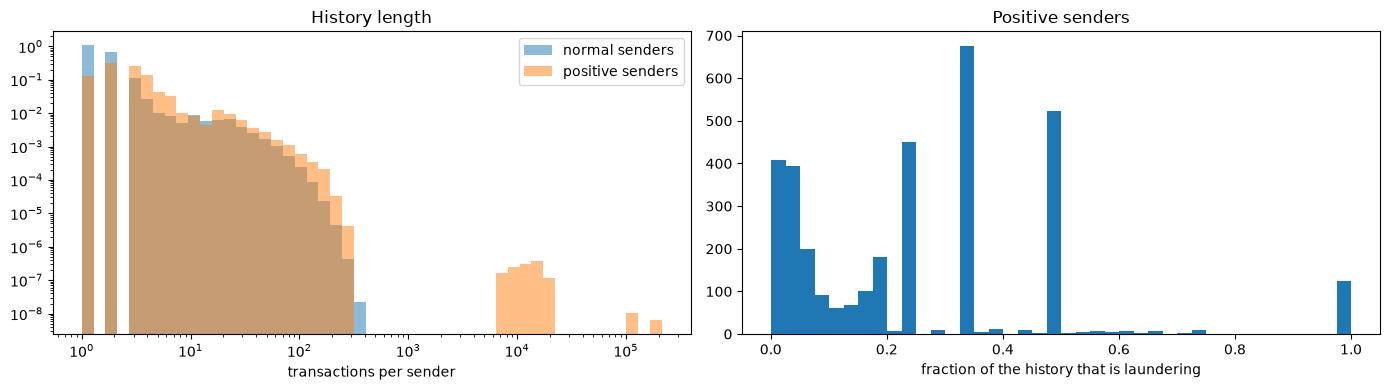

In [15]:
# order every sender's history chronologically; everything from here on relies on this order
df = df.sort_values(["sender", "ts", "tx_id"], kind="stable").reset_index(drop=True)
g = df.groupby("sender", sort=False)
sender_ntx = g["tx_id"].size()
sender_ever = g["is_laundering"].max()
counts = sender_ntx.to_numpy()
offsets = np.concatenate([[0], np.cumsum(counts)[:-1]])      # first row of each sender in df
assert (np.diff(df["sender"].to_numpy()) >= 0).all()

print(f"Senders: {len(counts):,} | positive senders (ever laundered): {int(sender_ever.sum()):,} "
      f"({sender_ever.mean():.3%})")
display(sender_ntx.describe(percentiles=[.25, .5, .75, .9, .95, .99, .999]).to_frame("transactions per sender").T)

rows = []
for k in [1, 2, 3, 4, 5, 10, 20]:
    short = counts < k
    rows.append({"min length": k, "% senders dropped": short.mean() * 100,
                 "% transactions dropped": counts[short].sum() / counts.sum() * 100,
                 "positive senders dropped": int(sender_ever.to_numpy()[short].sum()),
                 "% positive senders dropped": sender_ever.to_numpy()[short].sum() / sender_ever.sum() * 100})
display(pd.DataFrame(rows))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
bins = np.logspace(0, np.log10(counts.max()) + 0.1, 50)
ax[0].hist(counts[sender_ever.to_numpy() == 0], bins=bins, density=True, alpha=0.5, label="normal senders")
ax[0].hist(counts[sender_ever.to_numpy() == 1], bins=bins, density=True, alpha=0.5, label="positive senders")
ax[0].set_xscale("log"); ax[0].set_yscale("log"); ax[0].legend()
ax[0].set_xlabel("transactions per sender"); ax[0].set_title("History length")
pos = sender_ever.to_numpy() == 1
ax[1].hist(g["is_laundering"].mean().to_numpy()[pos], bins=40)
ax[1].set_xlabel("fraction of the history that is laundering"); ax[1].set_title("Positive senders")
plt.tight_layout(); plt.show()

**Hallazgos**

- 496,999 emisores; 3,376 (0.68%) lavan alguna vez. La mediana es de 2 transacciones por emisor y el percentil 75 de 5.
- Los positivos son especialmente cortos: largo mínimo 3 descarta 618 (18%); largo mínimo 2 descarta 122 (3.6%).

**Decisión: largo mínimo 2.**

Una sola transacción no forma una secuencia. Bajar de 3 a 2 recupera ~500 emisores positivos (+18%), que pesa cuando son tan escasos. Los emisores de una sola transacción (31%) quedan fuera del alcance de un modelo de secuencias (limitación).

In [16]:
MIN_LEN = 2

## 8. Largo de ventana, stride y tope

Cada emisor da ventanas de largo fijo `L`. Con a lo más `L` transacciones, una ventana con toda su historia. Con más, ventanas solapadas la primera termina en la transacción más reciente y cada siguiente empieza `stride` antes, hasta `cap` ventanas. Una ventana es positiva si contiene una transacción de lavado. La tabla compara configuraciones.

In [17]:
def plan_windows(n_tx, L, stride, cap):
    """Window layout for senders with n_tx transactions.
    Returns per window: owner (index into n_tx), rank (0 = most recent), start index, length."""
    n_tx = np.asarray(n_tx, dtype=np.int64)
    over = np.maximum(n_tx - L, 0)                          # transactions beyond a single window
    k_full = over // stride + 1                             # windows anchored at the most recent tx
    extra = (over % stride != 0).astype(np.int64)           # plus one window starting at tx 0
    n_win = np.minimum(k_full + extra, cap)
    owner = np.repeat(np.arange(len(n_tx)), n_win)
    rank = np.arange(n_win.sum()) - np.repeat(np.cumsum(n_win) - n_win, n_win)
    start = np.where(rank < k_full[owner], over[owner] - rank * stride, 0)
    length = np.minimum(n_tx[owner], L)
    return owner, rank, start, length

# helpers computed once: laundering prefix sums and the last laundering position of each sender
laund_arr = df["is_laundering"].to_numpy().astype(np.int64)
laund_prefix = np.concatenate([[0], np.cumsum(laund_arr)])
pos_in_sender = np.arange(len(df)) - np.repeat(offsets, counts)
last_laund = np.full(len(counts), -1, dtype=np.int64)
lm = laund_arr == 1
np.maximum.at(last_laund, np.repeat(np.arange(len(counts)), counts)[lm], pos_in_sender[lm])
N_POS_TOTAL = int((last_laund >= 0).sum())

def describe_config(min_len, L, stride, cap, n_features=9):
    elig = np.flatnonzero(counts >= min_len)
    owner, rank, start, length = plan_windows(counts[elig], L, stride, cap)
    first_row = offsets[elig][owner] + start
    pos_windows = (laund_prefix[first_row + length] - laund_prefix[first_row]) > 0
    n_win = np.bincount(owner, minlength=len(elig))
    oldest_start = start[np.cumsum(n_win) - 1]               # windows overlap, so coverage = [oldest_start, end)
    covered = last_laund[elig] >= oldest_start
    return {"min len": min_len, "L": L, "stride": stride, "cap": cap,
            "senders": len(elig), "windows": len(owner),
            "positive senders": int(covered.sum()),
            "% of all positive senders": covered.sum() / N_POS_TOTAL * 100,
            "positive windows": int(pos_windows.sum()),
            "positive window rate %": pos_windows.mean() * 100,
            "senders with >1 window": int((n_win > 1).sum()), "senders at cap": int((n_win == cap).sum()),
            "tx rows (with overlap)": int(length.sum()),
            "X_num GB": len(owner) * L * n_features * 4 / 1e9,
            "compute (windows×L, M)": len(owner) * L / 1e6}

grid = [(3, 64, 32, 8)]                                       # first version, for reference
grid += [(m, L, L // 2, 8) for m in (1, 2, 3) for L in (32, 48, 64) if (m, L) != (3, 64)]
grid += [(2, 32, 16, 12), (2, 32, 8, 8)]
config_tbl = pd.DataFrame([describe_config(*c) for c in grid])
pd.set_option("display.max_columns", 30)
display(config_tbl)
print(elapsed())

,min len,L,stride,cap,senders,windows,positive senders,% of all positive senders,positive windows,positive window rate %,senders with >1 window,senders at cap,tx rows (with overlap),X_num GB,"compute (windows×L, M)"
0,3,64,32,8,185993,205280,2747,81.3685,2909,1.4171,12847,27,5017478,0.4730,13.1379
1,1,32,16,8,496999,590607,3364,99.6445,3771,0.6385,41927,1448,6446170,0.6804,18.8994
2,1,48,24,8,496999,537489,3365,99.6742,3598,0.6694,23291,156,5910620,0.9288,25.7995
3,1,64,32,8,496999,516286,3365,99.6742,3527,0.6831,12847,27,5486736,1.1895,33.0423
4,2,32,16,8,344245,437853,3242,96.0308,3649,0.8334,41927,1448,6293416,0.5044,14.0113
5,2,48,24,8,344245,384735,3243,96.0604,3476,0.9035,23291,156,5757866,0.6648,18.4673
6,2,64,32,8,344245,363532,3243,96.0604,3405,0.9366,12847,27,5333982,0.8376,23.2660
7,3,32,16,8,185993,279601,2746,81.3389,3153,1.1277,41927,1448,5976912,0.3221,8.9472
8,3,48,24,8,185993,226483,2747,81.3685,2980,1.3158,23291,156,5441362,0.3914,10.8712
9,2,32,16,12,344245,439590,3243,96.0604,3657,0.8319,41927,156,6349000,0.5064,14.0669


[0.2 min]


**Hallazgos**

- El largo mínimo pesa más que el tamaño de ventana. Con mínimo 3 se conserva ~81% de los positivos, con mínimo 2 el ~96%.
- Con mínimo 2 el tamaño de ventana casi no cambia los positivos (~3,243) pero sí el costo. L=32 da 437,853 ventanas con 0.62 GB; L=64, 363,532 con 1.02 GB.
- Un tope de 12 ventanas deja 156 emisores en el tope (1,448 con tope 8) por solo 0.4% más ventanas. Un stride de 8 agrega ~50k ventanas y termina con menos positivos.

**Decisión: largo mínimo 2, ventanas de 32 transacciones, stride 16, máximo 12 ventanas por emisor.**

32 cubre toda la historia de la mayoría de emisores y alcanza para los intentos de lavado de la tipología (5 a 14 transacciones). Un patrón cortado por un borde aparece completo en la ventana siguiente. El tope evita que una cuenta muy activa domine el entrenamiento.

In [18]:
MAX_LEN = 32
STRIDE = 16
MAX_WINDOWS_PER_SENDER = 12
display(pd.DataFrame([describe_config(MIN_LEN, MAX_LEN, STRIDE, MAX_WINDOWS_PER_SENDER)]))

,min len,L,stride,cap,senders,windows,positive senders,% of all positive senders,positive windows,positive window rate %,senders with >1 window,senders at cap,tx rows (with overlap),X_num GB,"compute (windows×L, M)"
0,2,32,16,12,344245,439590,3243,96.0604,3657,0.8319,41927,156,6349000,0.5064,14.0669


## 9. Features de transacción

Cada transacción es intrínseca o **relativa a la historia del propio emisor**; no hay tiempo absoluto.

| Feature | Significado | Motivado por |
|---|---|---|
| `log_amt` | log(1 + monto en USD) | Parte 3: los montos abarcan 14 órdenes de magnitud |
| `amt_rel` | log del monto menos la mediana log de la ventana | Parte 3: "inusual para este emisor" |
| `log_gap` | log(1 + minutos desde la transacción previa del emisor) | Parte 4: solo tiempo relativo; ráfagas |
| `is_first` | primera transacción vista del emisor | no hay transacción previa para el gap |
| `is_self` | emisor == receptor | Parte 2 / 5: reinvestment |
| `same_bank` | mismo banco en ambos lados | movimiento entre bancos |
| `is_cross_currency` | se paga y recibe en monedas distintas | Parte 3 |
| `is_new_receiver` | primera vez que este emisor paga a este receptor | destinos que cambian abruptamente |
| `log_recv_senders` | log(1 + emisores distintos que le han pagado a este receptor **hasta ahora**) | Parte 6: fan-in / gather |
| `pay_format` | formato de pago (embedding aprendido) | Parte 5: concentración en ACH |
| `pay_currency` | moneda de pago (embedding aprendido) | Parte 3 |

`log_recv_senders` da contexto del receptor. Una secuencia por emisor no ve patrones de red (en un fan-in cada emisor hace un pago de aspecto ordinario). Se calcula punto-en-el-tiempo y sin etiquetas, así que no mira al futuro. Se calcula sobre todas las cuentas del dataset, algo que un banco real solo podría hacer con los receptores que observa (limitación).

**Normalización:** los features continuos se estandarizan con estadísticas de entrenamiento solamente (sección 11); los montos entran en log.

In [19]:
assert (np.diff(df["sender"].to_numpy()) >= 0).all(), "df must still be sorted by sender, time"
g = df.groupby("sender", sort=False)

gap_min = (df["ts"] - g["ts"].shift(1)).dt.total_seconds() / 60.0
df["is_first"] = gap_min.isna().astype(np.float32)
df["log_gap"] = np.log1p(gap_min.fillna(0).clip(lower=0)).astype(np.float32)
df["log_amt"] = np.log1p(df["amt_usd"].clip(lower=0)).astype(np.float32)

df["is_new_receiver"] = (~df.duplicated(["sender", "receiver"])).astype(np.float32)

# distinct senders that have paid each receiver up to (and including) this transaction, in time order
order = np.lexsort((df["tx_id"].to_numpy(), df["receiver"].to_numpy()))
r_sorted, s_sorted = df["receiver"].to_numpy()[order], df["sender"].to_numpy()[order]
new_pair = ~pd.DataFrame({"r": r_sorted, "s": s_sorted}).duplicated().to_numpy()
cum_senders = pd.Series(new_pair.astype(np.int64)).groupby(r_sorted).cumsum().to_numpy()
recv_senders = np.empty(len(df), dtype=np.int64)
recv_senders[order] = cum_senders
df["log_recv_senders"] = np.log1p(recv_senders).astype(np.float32)
del order, r_sorted, s_sorted, new_pair, cum_senders, recv_senders

FMT_NAMES = list(df["pay_format"].cat.categories.astype(str))
CUR_NAMES = list(df["pay_currency"].cat.categories.astype(str))
df["fmt_code"] = (df["pay_format"].cat.codes + 1).astype(np.int16)      # 0 is reserved for padding
df["cur_code"] = (df["pay_currency"].cat.codes + 1).astype(np.int16)

# analysis-only flags, never fed to the model
df["is_tail"] = (df["ts"] >= pd.Timestamp(TAIL_START)).astype(np.int8)
df["is_wr"] = df["pay_format"].astype(str).isin(WR_FORMATS).to_numpy().astype(np.int8)

NUM_FEATURES = ["log_amt", "amt_rel", "log_gap", "is_first", "is_self", "same_bank", "is_cross_currency",
                "is_new_receiver", "log_recv_senders"]
CONT_FEATURES = ["log_amt", "amt_rel", "log_gap", "log_recv_senders"]
del gap_min, g
print(f"Formats: {FMT_NAMES} | currencies: {len(CUR_NAMES)} {elapsed()}")

Formats: ['ACH', 'Bitcoin', 'Cash', 'Cheque', 'Credit Card', 'Reinvestment', 'Wire'] | currencies: 15 [0.3 min]


Chequeo: el feature de receptor sí trae información, sobre todo en fan-in.

In [20]:
chk = df.assign(recv_senders=np.expm1(df["log_recv_senders"]),
                group=np.where(df["is_laundering"] == 1, df["pattern"].fillna("laundering, no typology"), "normal"))
display(chk.groupby("group")["recv_senders"].describe(percentiles=[.5, .9])[["count", "50%", "90%", "mean"]]
          .sort_values("50%", ascending=False))
del chk

,count,50%,90%,mean
group,,,,
FAN-IN,318.0000,8.0000,15.0000,8.7075
GATHER-SCATTER,716.0000,5.0000,12.0000,5.9944
RANDOM,191.0000,4.0000,5.0000,3.5340
BIPARTITE,263.0000,4.0000,5.0000,3.4753
SCATTER-GATHER,626.0000,4.0000,12.0000,5.9105
CYCLE,287.0000,3.0000,5.4000,3.6098
FAN-OUT,342.0000,3.0000,5.0000,3.5760
STACK,466.0000,3.0000,5.0000,3.3519
"laundering, no typology","1,968.0000",3.0000,7.0000,4.3120


## 10. Construcción de secuencias

In [21]:
# --- windows for the chosen configuration
elig = counts >= MIN_LEN
e_ids, e_cnt, e_off = sender_ntx.index.to_numpy()[elig], counts[elig], offsets[elig]
win_owner, win_rank, win_start, win_len = plan_windows(e_cnt, MAX_LEN, STRIDE, MAX_WINDOWS_PER_SENDER)

N = len(win_start)
rep = np.repeat(np.arange(N), win_len)
pos = np.arange(win_len.sum()) - np.repeat(np.cumsum(win_len) - win_len, win_len)
rows = e_off[win_owner][rep] + win_start[rep] + pos

W_COLS = ["sender", "receiver", "tx_id", "ts", "amt_usd", "pay_format", "pay_currency", "fmt_code", "cur_code",
          "is_laundering", "pattern", "attempt_id", "is_tail", "is_wr"] + [f for f in NUM_FEATURES if f != "amt_rel"]
w = df[W_COLS].take(rows).reset_index(drop=True)
w["seq"] = rep.astype(np.int32)
w["pos"] = pos.astype(np.int16)
w["amt_rel"] = (w["log_amt"] - w.groupby("seq")["log_amt"].transform("median")).astype(np.float32)

# --- one row per window
seqs = w.groupby("seq").agg(
    sender=("sender", "first"), length=("pos", "size"), label=("is_laundering", "max"),
    n_laund=("is_laundering", "sum"), has_tail=("is_tail", "max"), only_wr=("is_wr", "min"),
    first_ts=("ts", "min"), last_ts=("ts", "max"))
assert (seqs.index.to_numpy() == np.arange(N)).all()
seqs["win_rank"] = win_rank
seqs["win_start"] = win_start
seqs["n_tx_total"] = e_cnt[win_owner]
seqs["ever_label"] = seqs["sender"].map(sender_ever).astype(np.int8)
seqs["sender_name"] = ACCOUNT_NAMES[seqs["sender"].to_numpy()]
seqs["pattern"] = (w.dropna(subset=["pattern"]).groupby("seq")["pattern"]
                     .agg(lambda s: s.value_counts().index[0])).reindex(seqs.index)

# --- one row per sender
senders = seqs.groupby("sender").agg(n_windows=("label", "size"), label=("label", "max"),
                                     has_tail=("has_tail", "max"), only_wr=("only_wr", "min"),
                                     n_tx_total=("n_tx_total", "first"), sender_name=("sender_name", "first"))
senders["ever_label"] = senders.index.map(sender_ever).astype(np.int8)
senders["pattern"] = (w.dropna(subset=["pattern"]).groupby("sender")["pattern"]
                        .agg(lambda s: s.value_counts().index[0])).reindex(senders.index)

print(f"Senders: {len(senders):,} | windows: {N:,} | positive senders: {int(senders.label.sum()):,} | "
      f"positive windows: {int(seqs.label.sum()):,}")
print(f"Positive senders lost to the window cap: {int(((senders.ever_label == 1) & (senders.label == 0)).sum()):,} "
      f"| transaction rows: {len(w):,} {elapsed()}")

Senders: 344,245 | windows: 439,590 | positive senders: 3,243 | positive windows: 3,657
Positive senders lost to the window cap: 11 | transaction rows: 6,349,000 [0.3 min]


In [22]:
# dense padded arrays: (N windows, MAX_LEN positions, F features), left-aligned, oldest first
L, F_NUM = MAX_LEN, len(NUM_FEATURES)
r, c = w["seq"].to_numpy(), w["pos"].to_numpy()

X_num = np.zeros((N, L, F_NUM), dtype=np.float32)
X_num[r, c] = w[NUM_FEATURES].to_numpy(np.float32)
X_fmt = np.zeros((N, L), dtype=np.int16); X_fmt[r, c] = w["fmt_code"].to_numpy()
X_cur = np.zeros((N, L), dtype=np.int16); X_cur[r, c] = w["cur_code"].to_numpy()
MASK = np.zeros((N, L), dtype=bool); MASK[r, c] = True
Y_TX = np.zeros((N, L), dtype=np.int8); Y_TX[r, c] = w["is_laundering"].to_numpy()   # analysis only
TX_ID = np.full((N, L), -1, dtype=np.int64); TX_ID[r, c] = w["tx_id"].to_numpy()
y_seq = seqs["label"].to_numpy().astype(np.int8)

print(f"X_num {X_num.shape}, {X_num.nbytes / 1e9:.2f} GB {elapsed()}")

X_num (439590, 32, 9), 0.51 GB [0.3 min]


## 11. Train, validación y test

El split es **por emisor**, no por ventana: ventanas solapadas del mismo emisor comparten transacciones, y una en train y otra en test filtraría información. Es 70/15/15, estratificado por si el emisor tiene una ventana positiva y si toca la cola. Solo con el set de entrenamiento se submuestrean los emisores puro Wire/Reinvestment y se calculan las medias y desviaciones de los features.

In [23]:
SPLIT_FRACS = (0.70, 0.15, 0.15)

def stratified_split(strata, fracs, seed):
    rng = np.random.default_rng(seed)
    out = np.empty(len(strata), dtype=np.int8)
    for s in np.unique(strata):
        idx = np.flatnonzero(strata == s)
        rng.shuffle(idx)
        n_tr = int(round(fracs[0] * len(idx)))
        n_va = int(round(fracs[1] * len(idx)))
        out[idx[:n_tr]], out[idx[n_tr:n_tr + n_va]], out[idx[n_tr + n_va:]] = 0, 1, 2
    return out

# split SENDERS, then every window inherits its sender's split
strata = senders["label"].to_numpy() * 2 + senders["has_tail"].to_numpy()
senders["split"] = np.array(["train", "val", "test"])[stratified_split(strata, SPLIT_FRACS, SEED)]

rng = np.random.default_rng(SEED + 1)
drop_wr = ((senders["split"] == "train") & (senders["only_wr"] == 1)
           & (rng.random(len(senders)) >= WR_ONLY_KEEP_FRAC))
assert senders.loc[drop_wr, "ever_label"].sum() == 0, "a dropped WR-only sender was positive"
senders["train_keep"] = (senders["split"] == "train") & ~drop_wr
print(f"Wire/Reinvestment-only senders in train: {int(((senders.split == 'train') & (senders.only_wr == 1)).sum()):,} "
      f"-> dropped {int(drop_wr.sum()):,}")

seqs["split"] = seqs["sender"].map(senders["split"])
seqs["train_keep"] = seqs["sender"].map(senders["train_keep"]).astype(bool)

# standardize continuous features with training statistics (valid positions only)
train_idx = np.flatnonzero(seqs["train_keep"].to_numpy())
NORM = {}
for f in CONT_FEATURES:
    j = NUM_FEATURES.index(f)
    vals = X_num[train_idx, :, j][MASK[train_idx]]
    mu, sd = float(vals.mean()), float(vals.std() + 1e-6)
    NORM[f] = {"mean": mu, "std": sd}
    X_num[:, :, j] = np.where(MASK, (X_num[:, :, j] - mu) / sd, 0.0)
display(pd.DataFrame(NORM).T)
print(elapsed())

Wire/Reinvestment-only senders in train: 40,413 -> dropped 32,371


,mean,std
log_amt,6.9571,2.7944
amt_rel,0.0485,2.2810
log_gap,3.7030,2.5359
log_recv_senders,1.3379,0.3346


[0.3 min]


In [24]:
SETS = {
    "stage_a_train": np.flatnonzero(seqs["train_keep"].to_numpy() & (seqs["ever_label"].to_numpy() == 0)),
    "stage_b_train": np.flatnonzero(seqs["train_keep"].to_numpy()),
    "val": np.flatnonzero((seqs["split"] == "val").to_numpy()),
    "test": np.flatnonzero((seqs["split"] == "test").to_numpy()),
}
PURPOSE = {"stage_a_train": "Stage A: learn normal behavior",
           "stage_b_train": "Stage B and baseline: supervised training",
           "val": "early stopping, thresholds, model choice",
           "test": "final results only"}

set_rows = []
for name, idx in SETS.items():
    sender_ids = np.unique(seqs["sender"].to_numpy()[idx])
    set_rows.append({"set": name, "used for": PURPOSE[name], "senders": len(sender_ids), "windows": len(idx),
                     "positive senders": int(senders.loc[sender_ids, "label"].sum()),
                     "positive windows": int(y_seq[idx].sum()),
                     "positive window rate %": y_seq[idx].mean() * 100})
    np.save(os.path.join(OUT_DIR, f"idx_{name}.npy"), idx)
display(pd.DataFrame(set_rows).set_index("set"))

sender_of = seqs["sender"].to_numpy()
train_s, val_s, test_s = (set(sender_of[SETS[k]]) for k in ("stage_b_train", "val", "test"))
assert not (train_s & val_s) and not (train_s & test_s) and not (val_s & test_s), "sender in two sets"
assert seqs.loc[SETS["stage_a_train"], "ever_label"].sum() == 0, "Stage A set contains laundering senders"
print("Sets are disjoint by sender; Stage A set is normal only.")

,used for,senders,windows,positive senders,positive windows,positive window rate %
set,,,,,,
stage_a_train,Stage A: learn normal behavior,206326,271896,0,0,0.0000
stage_b_train,Stage B and baseline: supervised training,208600,275316,2270,2557,0.9288
val,"early stopping, thresholds, model choice",51637,65886,487,563,0.8545
test,final results only,51637,66017,486,537,0.8134


Sets are disjoint by sender; Stage A set is normal only.


**Hallazgos**

- Etapa A entrena con 271,896 ventanas de emisores que nunca lavaron. Etapa B, con 275,316 ventanas de 208,600 emisores (2,270 positivos; 0.93% de ventanas positivas).
- Validación y test conservan a todos los emisores: 51,637 cada uno, con 487 y 486 positivos (0.94%).

## 12. Chequeos y ejemplos

Chequeos del pipeline y las vistas pedidas antes de modelar: balance de clases, distribución de largos y secuencias normales contra sospechosas.

In [25]:
# --- 7.1 Hard checks: if any of these fail, stop and fix the pipeline
assert (seqs.groupby("sender")["split"].nunique() == 1).all(), "a sender has windows in more than one split"
assert not seqs.duplicated(["sender", "win_start"]).any(), "duplicate windows"
assert seqs.groupby("sender").size().max() <= MAX_WINDOWS_PER_SENDER
latest = seqs[seqs.win_rank == 0]
assert (latest["win_start"] + latest["length"] == latest["n_tx_total"]).all(), "latest window must end at the last tx"
assert (MASK.sum(1) == seqs["length"].to_numpy()).all(), "mask does not match lengths"
assert seqs["length"].min() >= MIN_LEN and seqs["length"].max() <= MAX_LEN
assert MASK[:, 0].all(), "sequences must be left-aligned"
assert not X_num[~MASK].any() and not X_fmt[~MASK].any() and not X_cur[~MASK].any(), "padding not zero"
assert np.isfinite(X_num).all(), "NaN/inf in features"
assert (Y_TX.max(1) == y_seq).all(), "window label != any laundering tx in window"
assert X_fmt[MASK].min() >= 1 and X_cur[MASK].min() >= 1, "code 0 is reserved for padding"
assert (seqs.groupby("sender")["label"].max() == senders["label"]).all()
ts_ok = (w["ts"].diff().dt.total_seconds().fillna(0) >= 0) | (w["seq"] != w["seq"].shift())
assert ts_ok.all(), "transactions not in chronological order within a window"
for f in CONT_FEATURES:
    v = X_num[train_idx, :, NUM_FEATURES.index(f)][MASK[train_idx]]
    assert abs(v.mean()) < 1e-2 and abs(v.std() - 1) < 1e-2, f"{f} not standardized"
print("All pipeline checks passed.")

All pipeline checks passed.


,senders,positive senders,positive sender rate,windows,positive windows,positive window rate,senders with tail
train,"240,971.0000","2,270.0000",0.0094,"307,687.0000","2,557.0000",0.0083,279.0000
train (used),"208,600.0000","2,270.0000",0.0109,"275,316.0000","2,557.0000",0.0093,279.0000
val,"51,637.0000",487.0000,0.0094,"65,886.0000",563.0000,0.0085,60.0000
test,"51,637.0000",486.0000,0.0094,"66,017.0000",537.0000,0.0081,59.0000


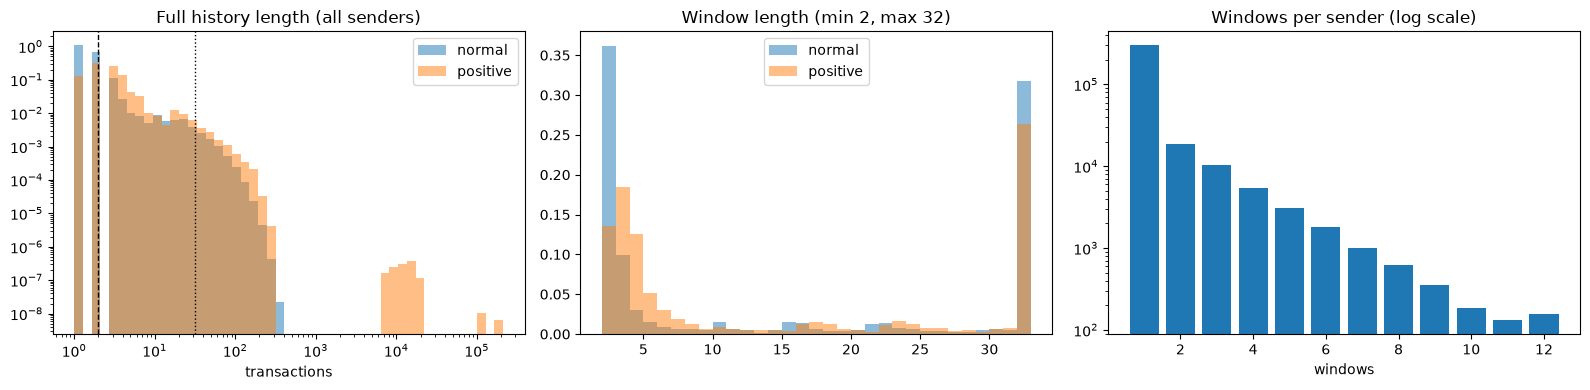

In [26]:
# --- 7.2 Class balance per split (senders and windows)
def balance(s_mask, w_mask):
    return {"senders": int(s_mask.sum()), "positive senders": int(senders.loc[s_mask, "label"].sum()),
            "positive sender rate": float(senders.loc[s_mask, "label"].mean()),
            "windows": int(w_mask.sum()), "positive windows": int(seqs.loc[w_mask, "label"].sum()),
            "positive window rate": float(seqs.loc[w_mask, "label"].mean()),
            "senders with tail": int(senders.loc[s_mask, "has_tail"].sum())}
bal = pd.DataFrame({
    "train": balance(senders.split == "train", seqs.split == "train"),
    "train (used)": balance(senders.train_keep, seqs.train_keep),
    "val": balance(senders.split == "val", seqs.split == "val"),
    "test": balance(senders.split == "test", seqs.split == "test"),
}).T
display(bal)

# --- 7.3 Sequence length distribution
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
bins_full = np.logspace(0, np.log10(sender_ntx.max()) + 0.1, 50)
ax[0].hist(sender_ntx[sender_ever == 0], bins=bins_full, alpha=0.5, density=True, label="normal")
ax[0].hist(sender_ntx[sender_ever == 1], bins=bins_full, alpha=0.5, density=True, label="positive")
ax[0].axvline(MIN_LEN, color="k", ls="--", lw=1); ax[0].axvline(MAX_LEN, color="k", ls=":", lw=1)
ax[0].set_xscale("log"); ax[0].set_yscale("log"); ax[0].legend()
ax[0].set_title("Full history length (all senders)"); ax[0].set_xlabel("transactions")

bins_w = np.arange(MIN_LEN, MAX_LEN + 2)
ax[1].hist(seqs.loc[seqs.label == 0, "length"], bins=bins_w, alpha=0.5, density=True, label="normal")
ax[1].hist(seqs.loc[seqs.label == 1, "length"], bins=bins_w, alpha=0.5, density=True, label="positive")
ax[1].set_title(f"Window length (min {MIN_LEN}, max {MAX_LEN})"); ax[1].legend()

wc = senders["n_windows"].value_counts().sort_index()
ax[2].bar(wc.index, wc.values); ax[2].set_yscale("log")
ax[2].set_title("Windows per sender (log scale)"); ax[2].set_xlabel("windows")
plt.tight_layout(); plt.show()

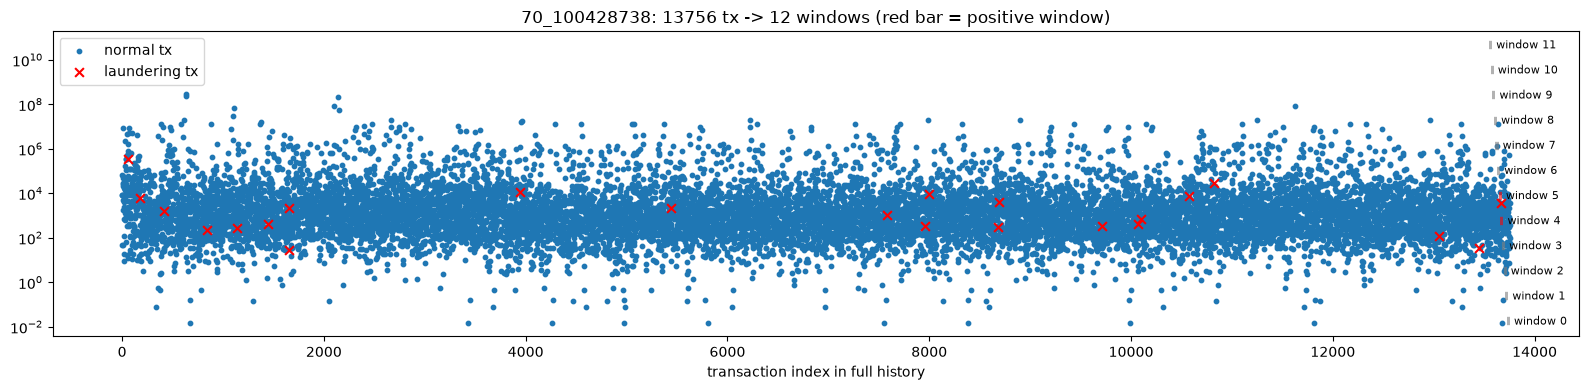

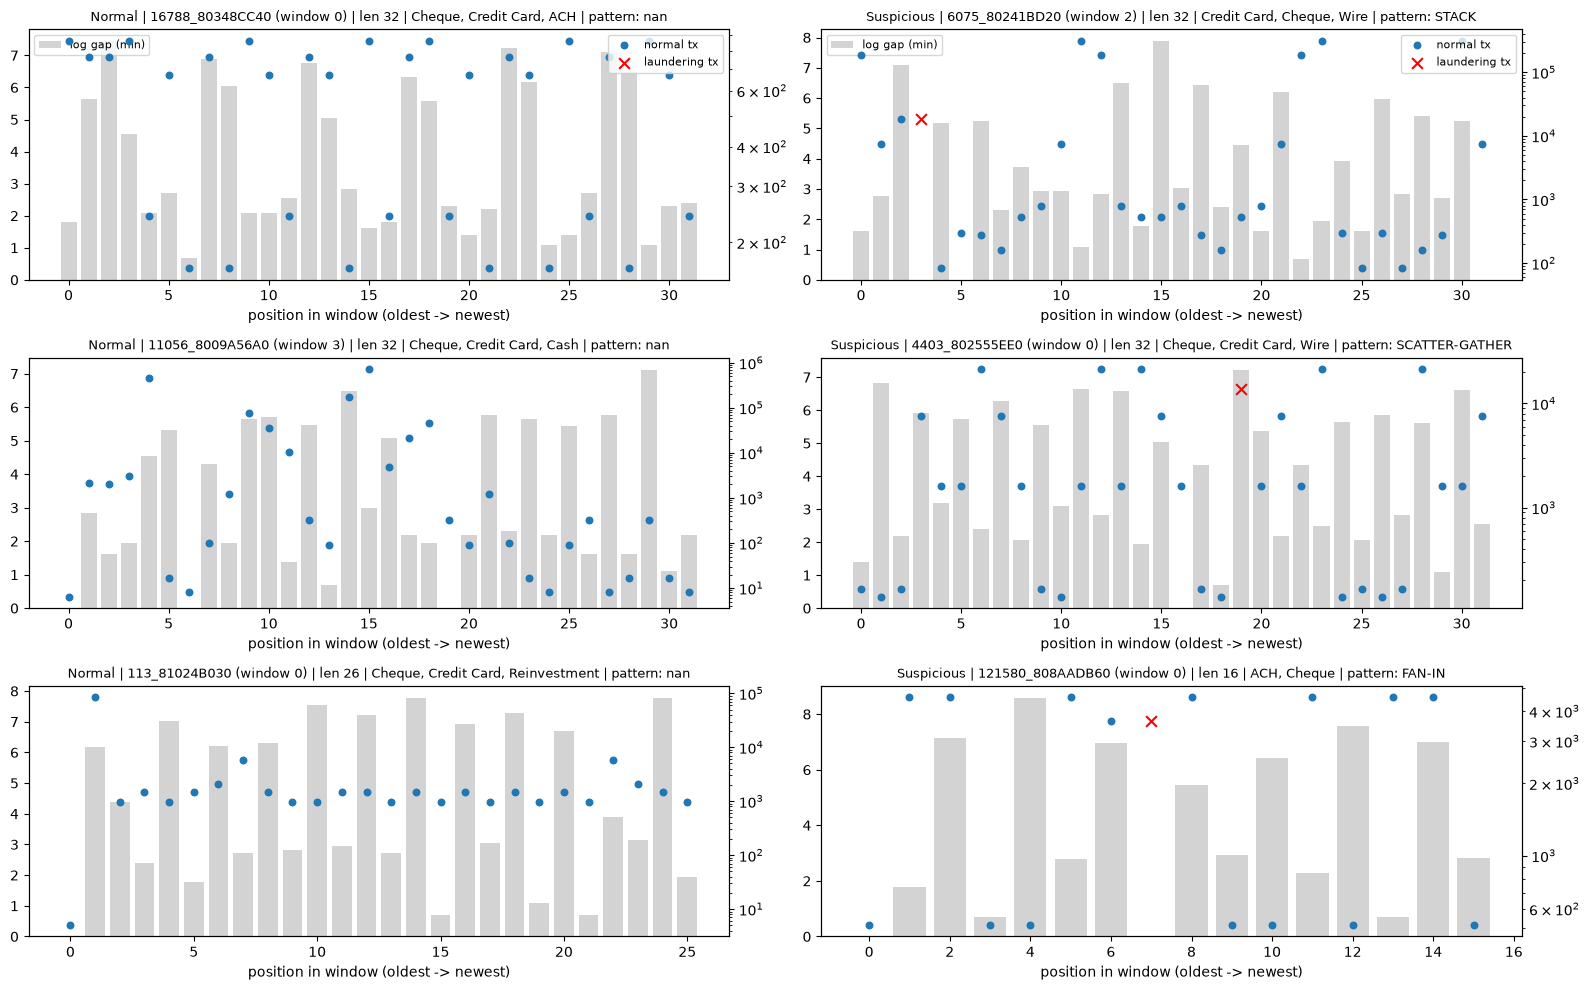

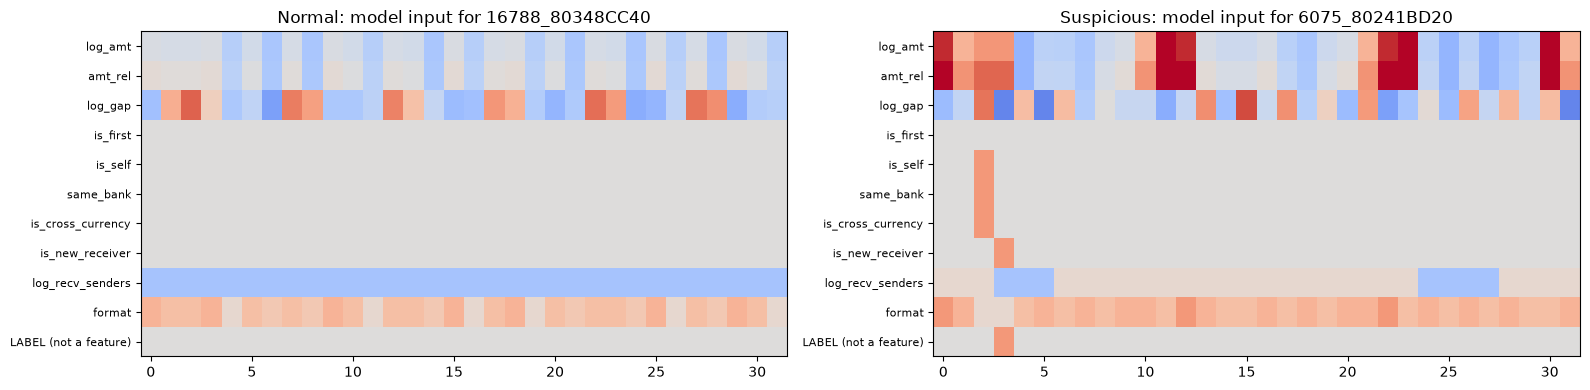

In [27]:
# --- 7.4 How sliding windows cover a long sender's history
cand = senders[(senders.n_windows >= 3)].sort_values(["label", "n_windows"], ascending=False)
if len(cand):
    sid = int(cand.index[0])
    k = int(np.flatnonzero(sender_ntx.index.to_numpy() == sid)[0])
    hist_rows = df.iloc[offsets[k]:offsets[k] + counts[k]]
    fig, ax = plt.subplots(figsize=(16, 4))
    bad = hist_rows["is_laundering"].to_numpy() == 1
    x = np.arange(len(hist_rows))
    ax.scatter(x[~bad], hist_rows["amt_usd"].to_numpy()[~bad], s=10, label="normal tx")
    ax.scatter(x[bad], hist_rows["amt_usd"].to_numpy()[bad], s=40, c="red", marker="x", label="laundering tx")
    ax.set_yscale("log")
    ymin, ymax = ax.get_ylim()
    for _, win in seqs[seqs.sender == sid].iterrows():
        y = ymin * (ymax / ymin) ** (0.05 + 0.1 * win.win_rank)
        ax.hlines(y, win.win_start, win.win_start + win.length - 1, lw=6, alpha=0.6,
                  color="red" if win.label else "gray")
        ax.text(win.win_start + win.length, y, f" window {win.win_rank}", va="center", fontsize=8)
    ax.set_title(f"{senders.loc[sid, 'sender_name']}: {counts[k]} tx -> {senders.loc[sid, 'n_windows']} windows "
                 f"(red bar = positive window)")
    ax.set_xlabel("transaction index in full history"); ax.legend(loc="upper left")
    plt.tight_layout(); plt.show()

# --- 7.5 Example sequences: 3 normal vs 3 suspicious windows (raw values, before normalization)
rng = np.random.default_rng(SEED)
def pick(label, k=3, min_len=15):
    cand = seqs[(seqs.label == label) & (seqs.length >= min_len)].index.to_numpy()
    if len(cand) < k:
        cand = seqs[seqs.label == label].index.to_numpy()
    return rng.choice(cand, size=min(k, len(cand)), replace=False)

examples = {"Normal": pick(0), "Suspicious": pick(1)}
fig, axes = plt.subplots(3, 2, figsize=(16, 10), squeeze=False)
for col, (kind, ids) in enumerate(examples.items()):
    for row in range(3):
        ax = axes[row, col]
        if row >= len(ids):
            ax.axis("off"); continue
        s = w[w["seq"] == ids[row]]
        bad = s["is_laundering"] == 1
        ax.bar(s["pos"], s["log_gap"], color="lightgray", label="log gap (min)")
        ax2 = ax.twinx()
        ax2.scatter(s.loc[~bad, "pos"], s.loc[~bad, "amt_usd"], s=22, label="normal tx")
        ax2.scatter(s.loc[bad, "pos"], s.loc[bad, "amt_usd"], s=60, c="red", marker="x", label="laundering tx")
        ax2.set_yscale("log")
        meta = seqs.loc[ids[row]]
        fmts = ", ".join(s["pay_format"].astype(str).value_counts().index[:3])
        ax.set_title(f"{kind} | {meta.sender_name} (window {meta.win_rank}) | len {meta.length} | {fmts} | "
                     f"pattern: {meta.pattern}", fontsize=9)
        ax.set_xlabel("position in window (oldest -> newest)")
        if row == 0:
            ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

# feature matrix view (what the model actually sees), one normal and one suspicious
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, (kind, ids) in zip(axes, examples.items()):
    i = ids[0]; n_i = int(MASK[i].sum())
    mat = np.vstack([X_num[i, :n_i].T, X_fmt[i, :n_i] / len(FMT_NAMES), Y_TX[i, :n_i]])
    ax.imshow(mat, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
    ax.set_yticks(range(len(NUM_FEATURES) + 2))
    ax.set_yticklabels(NUM_FEATURES + ["format", "LABEL (not a feature)"], fontsize=8)
    ax.set_title(f"{kind}: model input for {seqs.loc[i, 'sender_name']}")
plt.tight_layout(); plt.show()

**Ejemplos**

Las secuencias sospechosas no se distinguen a simple vista, al ver las gráficas técnicamente si podríamos decir que se ven "anómalas" pero cualquier intento de generalización de alguna regla falla inmediatamente. Por ejemplo, en el tercer ejemplo de transacción de lavado podemos ver que la transacción se hizo sin tener algún gap mientras los demás si tienen. Pero viendo el segundo ejemplo, aquí la transacción de lavado tiene un gap significativamente mayor a los demás. Por lo tanto, los patrones que debemos buscar son  más robustos. 

### Resumen de decisiones (Componente 1)

| Decisión | Elección | Justificación |
|---|---|---|
| Features | 9 numéricos + formato + moneda, relativos al emisor; sin tiempo absoluto ni hora | Secciones 3–6: artefactos del simulador |
| Normalización | log(1 + monto en USD); z-score con estadísticas de entrenamiento | Montos de 14 órdenes de magnitud; sin fuga entre splits |
| Largo mínimo | 2 transacciones | Recupera ~500 emisores positivos (+18%) |
| Largo máximo | Ventanas de 32, stride 16, máximo 12 por emisor | Sección 8: cubre la historia de casi todos los emisores y los intentos de lavado |
| Desbalance | Submuestreo de emisores puro Wire/Reinvestment en entrenamiento; sampling 40:1 y focal loss en la Etapa B; métricas basadas en PR | Secciones 5, 13 y 15 |
| Splits | 70/15/15 por emisor, estratificado por positivo y por cola; estadísticas solo de entrenamiento | Las ventanas solapadas comparten transacciones |

### Guardar datos procesados

In [28]:
def save_table(frame, name):
    try:
        frame.to_parquet(os.path.join(OUT_DIR, name + ".parquet"), index=False)
    except ImportError:
        frame.to_csv(os.path.join(OUT_DIR, name + ".csv"), index=False)

np.save(os.path.join(OUT_DIR, "X_num.npy"), X_num)
np.save(os.path.join(OUT_DIR, "X_fmt.npy"), X_fmt)
np.save(os.path.join(OUT_DIR, "X_cur.npy"), X_cur)
np.save(os.path.join(OUT_DIR, "MASK.npy"), MASK)
np.save(os.path.join(OUT_DIR, "Y_TX.npy"), Y_TX)
np.save(os.path.join(OUT_DIR, "TX_ID.npy"), TX_ID)
save_table(seqs.reset_index(), "windows")
save_table(senders.reset_index(), "senders")

# readable transactions for val/test windows (needed later for interpretability and the MVP)
eval_seq = seqs.index[seqs["split"].isin(["val", "test"])]
tx_view = w[w["seq"].isin(eval_seq)].copy()
tx_view["receiver_name"] = ACCOUNT_NAMES[tx_view["receiver"].to_numpy()]
tx_view["pay_format"] = tx_view["pay_format"].astype(str)
tx_view["pay_currency"] = tx_view["pay_currency"].astype(str)
save_table(tx_view[["seq", "pos", "sender", "tx_id", "ts", "receiver_name", "amt_usd", "pay_format",
                    "pay_currency", "is_laundering", "pattern", "is_tail"]], "eval_transactions")

META = {"NUM_FEATURES": NUM_FEATURES, "CONT_FEATURES": CONT_FEATURES, "NORM": NORM,
        "FMT_NAMES": FMT_NAMES, "CUR_NAMES": CUR_NAMES,
        "config": {"SEED": SEED, "MAX_LEN": MAX_LEN, "STRIDE": STRIDE,
                   "MAX_WINDOWS_PER_SENDER": MAX_WINDOWS_PER_SENDER, "MIN_LEN": MIN_LEN,
                   "TAIL_START": TAIL_START, "WR_FORMATS": WR_FORMATS,
                   "WR_ONLY_KEEP_FRAC": WR_ONLY_KEEP_FRAC, "SPLIT_FRACS": SPLIT_FRACS},
        "rates_to_usd": {k: float(v) for k, v in rates.items()}}
with open(os.path.join(OUT_DIR, "meta.json"), "w") as f:
    json.dump(META, f, indent=2)

# free the transaction tables; everything below uses the arrays + seqs/senders
del df, w, tx_view, rows, rep, pos
gc.collect()
print(sorted(os.listdir(OUT_DIR)), elapsed())

['MASK.npy', 'TX_ID.npy', 'X_cur.npy', 'X_fmt.npy', 'X_num.npy', 'Y_TX.npy', 'ablation_results.csv', 'eval_transactions.parquet', 'final_system.json', 'final_test_senders.parquet', 'idx_stage_a_train.npy', 'idx_stage_b_train.npy', 'idx_test.npy', 'idx_val.npy', 'meta.json', 'poolw_a.npy', 'senders.parquet', 'stage_a.pt', 'stage_a_history.csv', 'stage_a_lstm.pt', 'stage_a_lstm_history.csv', 'stage_a_lstm_scoring_candidates.csv', 'stage_a_mlp.pt', 'stage_a_mlp_history.csv', 'stage_a_mlp_scoring_candidates.csv', 'stage_a_results.csv', 'stage_a_scoring_candidates.csv', 'stage_a_transformer.pt', 'stage_a_transformer_history.csv', 'stage_a_transformer_scoring_candidates.csv', 'stage_b.pt', 'stage_b_test_attention.npy', 'txerr_a.npy', 'window_score_a.npy', 'windows.parquet'] [0.4 min]


## 13. Métricas

Con 0.10% de positivos, un modelo que nunca alerta tiene 99.9% de accuracy, así que no se usa. Todo se evalúa **por emisor** (la unidad que recibe una alerta), no por ventana.

| Métrica | Para qué |
|---|---|
| PR-AUC | Calidad del ranking completo. Es la métrica de selección en validación. Un ranking aleatorio da la tasa positiva (~0.0094). |
| Recall @5% | Si el equipo revisa el 5% de emisores más riesgosos (~2,580), qué fracción de lavadores encuentra. Mide carga de trabajo. |
| Precision @100 | De las 100 alertas más altas, cuántas son reales. Los sistemas por reglas rondan 1–5%, según el enunciado. |
| Precision / recall en el umbral | Un corte concreto: el puntaje que alerta al 5% de los emisores en validación, aplicado igual a test. |

Los números de test llevan intervalos bootstrap del 95% sobre emisores de test.

In [29]:
def average_precision(y, s):
    o = np.argsort(-s, kind="mergesort"); ys = y[o]
    precision = np.cumsum(ys) / np.arange(1, len(ys) + 1)
    return float((precision * ys).sum() / max(ys.sum(), 1))

def roc_auc(y, s):
    ranks = pd.Series(s).rank().to_numpy(); n1 = y.sum(); n0 = len(y) - n1
    return float((ranks[y == 1].sum() - n1 * (n1 + 1) / 2) / max(n1 * n0, 1))

def recall_at_budget(y, s, frac):
    k = max(1, int(round(len(y) * frac))); o = np.argsort(-s, kind="mergesort")
    return float(y[o[:k]].sum() / max(y.sum(), 1))

def precision_at_k(y, s, k=100):
    o = np.argsort(-s, kind="mergesort")
    return float(y[o[:k]].mean())

def best_f1_threshold(y, s):
    o = np.argsort(-s, kind="mergesort"); ys, ss = y[o], s[o]
    tp = np.cumsum(ys); k = np.arange(1, len(ys) + 1)
    prec, rec = tp / k, tp / max(ys.sum(), 1)
    f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-12)
    return float(ss[int(f1.argmax())])

def evaluate(y, s, thr=None):
    y = np.asarray(y).astype(np.int64); s = np.asarray(s, dtype=np.float64)
    out = {"PR-AUC": average_precision(y, s)}
    out["lift vs random"] = out["PR-AUC"] / max(y.mean(), 1e-12)
    out.update({"ROC-AUC": roc_auc(y, s), "P@100": precision_at_k(y, s, 100),
                "recall @1%": recall_at_budget(y, s, 0.01), "recall @5%": recall_at_budget(y, s, 0.05)})
    if thr is not None:
        pred = s >= thr; tp = int((pred & (y == 1)).sum())
        p, r = tp / max(pred.sum(), 1), tp / max(y.sum(), 1)
        out.update({"precision @thr": p, "recall @thr": r, "F1 @thr": 2 * p * r / max(p + r, 1e-12),
                    "alert rate @thr": float(pred.mean())})
    return out

def bootstrap_ci(y, s, fn, n_boot=200, seed=SEED):
    rng = np.random.default_rng(seed); y = np.asarray(y); s = np.asarray(s, dtype=np.float64)
    vals = [fn(y[i], s[i]) for i in (rng.integers(0, len(y), len(y)) for _ in range(n_boot))]
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

# sender-level view of any per-window score
SENDER_OF = seqs["sender"].to_numpy()
LEN = MASK.sum(1)
def to_senders(window_scores, idx, agg="max"):
    """window_scores covers ALL windows (global index); idx selects the windows to aggregate."""
    return pd.Series(np.asarray(window_scores)[idx], index=SENDER_OF[idx]).groupby(level=0).agg(agg)

def local_to_senders(values, idx, agg="max"):
    """values[i] belongs to window idx[i] (e.g. predictions made only on the validation windows)."""
    return pd.Series(np.asarray(values), index=SENDER_OF[idx]).groupby(level=0).agg(agg)

VAL_SENDERS = np.unique(SENDER_OF[SETS["val"]])
TEST_SENDERS = np.unique(SENDER_OF[SETS["test"]])
Y_VAL = senders.loc[VAL_SENDERS, "label"].to_numpy()
Y_TEST = senders.loc[TEST_SENDERS, "label"].to_numpy()
print(f"Validation: {len(VAL_SENDERS):,} senders ({Y_VAL.sum()} positive) | "
      f"test: {len(TEST_SENDERS):,} senders ({Y_TEST.sum()} positive)")

Validation: 51,637 senders (487 positive) | test: 51,637 senders (486 positive)


# Componente 2: Sistema de detección en dos etapas

## 14. Etapa A: aprender lo normal

Hay muy pocos positivos y el lavado cambia de forma, así que aprender cómo se ve lo normal (que es lo abundante) da un puntaje de anomalía sin necesitar etiquetas. Se entrena solo con ventanas de emisores que nunca lavaron. Un autoencoder comprime cada ventana a 32 números (`z`) y la reconstruye; el **error de reconstrucción es el puntaje de anomalía**.

```
ventana (32 tx × 9 features numéricos + formato + moneda) → embedding → ENCODER → attention pooling → z (32) → DECODER → ventana reconstruida
```

**Arquitectura.** Procesa largo variable (el padding se enmascara), produce una representación comprimida y reconstruye la secuencia original. El decoder solo recibe `z` y la posición que debe llenar: si viera la ventana original la copiaría, anomalías incluidas, y `z` no tendría que guardar nada. Los encoders LSTM y Transformer terminan en un attention pooling, porque las ventanas tienen largo variable y da un peso por transacción que luego sirve de heatmap. El loss es el error cuadrático en los features numéricos más cross-entropy en formato y moneda, solo sobre transacciones reales.

Se comparan tres encoders con el mismo loss y la misma receta de entrenamiento, para que la diferencia sea solo la arquitectura:

| Encoder | Cómo lee la ventana | Motivo |
|---|---|---|
| MLP (baseline) | La ventana aplanada, con capas densas. No modela secuencia | Piso / Baseline |
| LSTM | Bidireccional, de 2 capas, una transacción a la vez con una memoria (compuertas forget, input, output) | Las transacciones tienen orden y importa qué pasó antes (Lab-02) |
| Transformer | 2 capas de self-attention: cada transacción mira a todas las demás | Captura relaciones entre transacciones lejanas de la ventana (montos repetidos, un pago que solo es raro junto a otro) y se usa en detección de anomalías en series de tiempo |

**Conexión con el curso:** LSTM (Lab-02), encoder-decoder (Lab-03), atención y Transformers (Lab-04, Proy-01).

In [30]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "no GPU (will be slow)")

CFG_A = dict(d_model=64, n_heads=4, n_layers=2, d_ff=128, z_dim=32, dec_layers=1, rnn_layers=2, mlp_hidden=256, dropout=0.1,
             lr=1e-3, weight_decay=1e-4, batch_size=1024, max_epochs=100, patience=5,
             w_cat=0.5, max_train=250_000, max_val=30_000)
N_FMT, N_CUR = len(FMT_NAMES), len(CUR_NAMES)

Device: cuda | NVIDIA GeForce RTX 4070 SUPER


In [31]:
class TransactionEmbedding(nn.Module):
    """Numeric features + format/currency embeddings + learned position -> one d_model vector per tx."""
    def __init__(self, n_num, n_fmt, n_cur, d_model, max_len):
        super().__init__()
        self.num_proj = nn.Linear(n_num, d_model)
        self.fmt_emb = nn.Embedding(n_fmt + 1, d_model, padding_idx=0)
        self.cur_emb = nn.Embedding(n_cur + 1, d_model, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x_num, x_fmt, x_cur):
        pos = torch.arange(x_num.size(1), device=x_num.device)
        h = self.num_proj(x_num) + self.fmt_emb(x_fmt) + self.cur_emb(x_cur) + self.pos_emb(pos)[None]
        return self.norm(h)


class AttentionPooling(nn.Module):
    """Learned weighted average over transactions -> one vector per sequence + one weight per transaction."""
    def __init__(self, d_model, d_attn=64):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(d_model, d_attn), nn.Tanh(), nn.Linear(d_attn, 1))

    def forward(self, h, pad_mask):
        s = self.score(h).squeeze(-1).masked_fill(pad_mask, float("-inf"))
        a = torch.softmax(s, dim=-1)                          # (B, L), sums to 1 over real transactions
        return (a.unsqueeze(-1) * h).sum(1), a


def reconstruction_errors(rec, x_num, x_fmt, x_cur, valid, w_cat):
    """Per-transaction error (B, L), zero on padding, and per-sequence mean error (B,)."""
    rec_num, rec_fmt, rec_cur = rec
    err = ((rec_num - x_num) ** 2).mean(-1)
    err = err + w_cat * (F.cross_entropy(rec_fmt.transpose(1, 2), x_fmt, reduction="none")
                         + F.cross_entropy(rec_cur.transpose(1, 2), x_cur, reduction="none"))
    per_tx = err * valid
    return per_tx, per_tx.sum(1) / valid.sum(1)


def to_device(idx):
    """Index the numpy arrays and move one set of sequences to the device."""
    idx = np.asarray(idx)
    return (torch.from_numpy(X_num[idx]).to(DEVICE),
            torch.from_numpy(X_fmt[idx].astype(np.int64)).to(DEVICE),
            torch.from_numpy(X_cur[idx].astype(np.int64)).to(DEVICE),
            torch.from_numpy(MASK[idx]).to(DEVICE))


# --- Training data: training senders that NEVER laundered (normal only), shared by Step 0 and Step 1
rng = np.random.default_rng(SEED)
tr_a = SETS["stage_a_train"].copy()
if len(tr_a) > CFG_A["max_train"]:
    tr_a = np.sort(rng.choice(tr_a, CFG_A["max_train"], replace=False))
va_a = np.flatnonzero((seqs["split"] == "val").to_numpy() & (seqs["ever_label"].to_numpy() == 0))
if len(va_a) > CFG_A["max_val"]:
    va_a = np.sort(rng.choice(va_a, CFG_A["max_val"], replace=False))
assert seqs.loc[tr_a, "ever_label"].sum() == 0, "Stage A training set contains laundering senders"
print(f"Stage A train: {len(tr_a):,} windows of normal senders | early-stopping val: {len(va_a):,} windows")

TR = to_device(tr_a)      # whole training set on the GPU: much faster than a DataLoader for this size
VA = to_device(va_a)


def eval_loss(model, data, bs=2048):
    model.eval(); total = 0.0
    with torch.no_grad():
        for s in range(0, data[0].size(0), bs):
            b = [t[s:s + bs] for t in data]
            total += reconstruction_errors(model(*b)[1], *b, CFG_A["w_cat"])[1].sum().item()
    return total / data[0].size(0)


def fit_autoencoder(model, name):
    """AdamW + one epoch of warmup + cosine decay, gradient clipping, early stopping on normal-validation loss.
    Loads the best weights into `model` and returns the training history."""
    opt = torch.optim.AdamW(model.parameters(), lr=CFG_A["lr"], weight_decay=CFG_A["weight_decay"])
    steps_per_epoch = math.ceil(len(tr_a) / CFG_A["batch_size"])
    total_steps, warmup = CFG_A["max_epochs"] * steps_per_epoch, steps_per_epoch
    def lr_lambda(step):
        if step < warmup:
            return (step + 1) / warmup
        p = min(1.0, (step - warmup) / max(1, total_steps - warmup))
        return max(0.05, 0.5 * (1 + math.cos(math.pi * p)))
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)

    history, best, best_state, bad_epochs = [], float("inf"), None, 0
    gen = torch.Generator().manual_seed(SEED)
    for epoch in range(1, CFG_A["max_epochs"] + 1):
        t_ep = time.time(); model.train(); run = 0.0
        order = torch.randperm(len(tr_a), generator=gen).to(DEVICE)
        for s in range(0, len(tr_a), CFG_A["batch_size"]):
            bi = order[s:s + CFG_A["batch_size"]]
            b = [t[bi] for t in TR]
            loss = reconstruction_errors(model(*b)[1], *b, CFG_A["w_cat"])[1].mean()
            opt.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
            run += loss.item() * len(bi)
        tr_loss, va_loss = run / len(tr_a), eval_loss(model, VA)
        history.append({"epoch": epoch, "train": tr_loss, "val_normal": va_loss})
        improved = va_loss < best - 1e-4
        if improved:
            best, bad_epochs = va_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1
        stop = bad_epochs >= CFG_A["patience"]
        if epoch == 1 or epoch % 10 == 0 or stop or epoch == CFG_A["max_epochs"]:
            print(f"{name} epoch {epoch:3d} | train {tr_loss:.4f} | val(normal) {va_loss:.4f} {'*' if improved else ''} "
                  f"| {time.time() - t_ep:.0f}s {elapsed()}")
        if stop:
            print(f"{name}: early stopping at epoch {epoch}."); break
    model.load_state_dict(best_state)
    return pd.DataFrame(history)


@torch.no_grad()
def score_windows(model, idx, bs=4096):
    """Reconstruction error per window and per transaction (+ pooling weights, for models that have them)."""
    model.eval()
    scores, per_tx_all, pool_all = [], [], []
    for s in range(0, len(idx), bs):
        b = to_device(idx[s:s + bs])
        enc, rec = model(*b)
        per_tx, per_seq = reconstruction_errors(rec, *b, CFG_A["w_cat"])
        scores.append(per_seq.cpu()); per_tx_all.append(per_tx.cpu())
        if "pool_weights" in enc:
            pool_all.append(enc["pool_weights"].cpu())
    return (torch.cat(scores).numpy(), torch.cat(per_tx_all).numpy(),
            torch.cat(pool_all).numpy() if pool_all else None)


def length_normalize(raw, ref_idx, min_count=500):
    """log(raw) standardized by the mean/std of normal reference windows of the same length."""
    lr = np.log(np.asarray(raw) + 1e-6)
    mu, sd = np.zeros(MAX_LEN + 1), np.ones(MAX_LEN + 1)
    ref_len, ref_val = LEN[ref_idx], lr[ref_idx]
    for L in range(1, MAX_LEN + 1):
        k = 0
        while True:
            sel = (ref_len >= L - k) & (ref_len <= L + k)
            if sel.sum() >= min_count or k >= MAX_LEN:
                break
            k += 1
        if sel.any():
            mu[L], sd[L] = ref_val[sel].mean(), ref_val[sel].std() + 1e-6
    return (lr - mu[LEN]) / sd[LEN]


def rank_window_scores(score, txerr):
    """Try the candidate window scores x sender aggregations on validation. Returns (candidates, ranked table)."""
    err = np.where(MASK, txerr, np.nan)
    top3 = -np.sort(-np.nan_to_num(err, nan=-np.inf), axis=1)[:, :3]
    top3 = np.nanmean(np.where(np.isfinite(top3), top3, np.nan), axis=1)
    cands = {
        "mean error (previous)": score,
        "mean error, length-normalized": length_normalize(score, SETS["stage_a_train"]),
        "top-3 error, length-normalized": length_normalize(top3, SETS["stage_a_train"]),
    }
    rows = []
    for wname, ws in cands.items():
        for agg in ["max", "mean"]:
            sv = to_senders(ws, SETS["val"], agg).reindex(VAL_SENDERS).to_numpy()
            rows.append({"window score": wname, "over a sender's windows": agg, **evaluate(Y_VAL, sv)})
    return cands, pd.DataFrame(rows).sort_values("PR-AUC", ascending=False)

def alert_top(s, frac=0.05):
    """Boolean mask: the top `frac` of senders by score (the alert budget)."""
    k = int(round(len(s) * frac)); a = np.zeros(len(s), bool); a[np.argsort(-s, kind="mergesort")[:k]] = True
    return a


def budget_threshold(s, frac=0.05):
    """Score cutoff that alerts the top `frac` of senders. Computed on validation, applied as-is to test."""
    s = np.sort(np.asarray(s, dtype=np.float64))[::-1]
    return float(s[max(1, int(round(len(s) * frac))) - 1])

Stage A train: 250,000 windows of normal senders | early-stopping val: 30,000 windows


### Modelo 1: MLP (baseline)

Aplana la ventana, la comprime a `z` y la reconstruye con capas densas. No modela secuencia; es el piso de comparación.

In [32]:
class MLPAutoencoder(nn.Module):
    """Step 0 baseline: flatten the window -> z -> flat reconstruction. Same interface as the other autoencoders."""
    def __init__(self, cfg, emb_dim=4):
        super().__init__()
        self.L, self.n_out = MAX_LEN, F_NUM + (N_FMT + 1) + (N_CUR + 1)
        self.fmt_emb = nn.Embedding(N_FMT + 1, emb_dim, padding_idx=0)
        self.cur_emb = nn.Embedding(N_CUR + 1, emb_dim, padding_idx=0)
        h = cfg["mlp_hidden"]
        self.enc = nn.Sequential(nn.Linear(self.L * (F_NUM + 2 * emb_dim), h), nn.ReLU(), nn.Dropout(cfg["dropout"]),
                                 nn.Linear(h, cfg["z_dim"]))
        self.dec = nn.Sequential(nn.Linear(cfg["z_dim"], h), nn.ReLU(), nn.Dropout(cfg["dropout"]),
                                 nn.Linear(h, self.L * self.n_out))

    def forward(self, x_num, x_fmt, x_cur, valid):
        x = torch.cat([x_num * valid[..., None], self.fmt_emb(x_fmt), self.cur_emb(x_cur)], dim=-1).flatten(1)
        z = self.enc(x)
        out = self.dec(z).view(-1, self.L, self.n_out)
        rec = (out[..., :F_NUM], out[..., F_NUM:F_NUM + N_FMT + 1], out[..., F_NUM + N_FMT + 1:])
        return {"z": z}, rec


torch.manual_seed(SEED)
A_MODELS = {"MLP": MLPAutoencoder(CFG_A).to(DEVICE)}

### Modelo 2: LSTM

LSTM bidireccional de 2 capas (sin procesar el padding) y attention pooling hacia `z`. El decoder LSTM recibe `z` como estado inicial y como entrada en cada paso.

In [33]:
class LSTMEncoder(nn.Module):
    """Bidirectional LSTM over transaction embeddings -> per-tx vectors -> attention pooling -> z.
    Shared between Stage A and Stage B."""
    def __init__(self, n_num, n_fmt, n_cur, max_len, d_model, n_layers, z_dim, dropout):
        super().__init__()
        self.embed = TransactionEmbedding(n_num, n_fmt, n_cur, d_model, max_len)
        self.lstm = nn.LSTM(d_model, d_model // 2, num_layers=n_layers, batch_first=True, bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.final_ln = nn.LayerNorm(d_model)
        self.pool = AttentionPooling(d_model)
        self.to_z = nn.Linear(d_model, z_dim)

    def forward(self, x_num, x_fmt, x_cur, valid):
        h = self.embed(x_num, x_fmt, x_cur)
        packed = nn.utils.rnn.pack_padded_sequence(h, valid.sum(1).cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)                                    # padding is never processed
        h, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True, total_length=x_num.size(1))
        h = self.final_ln(h)
        pooled, pool_w = self.pool(h, ~valid)
        return {"z": self.to_z(pooled), "h": h, "pooled": pooled, "pool_weights": pool_w}


class LSTMDecoder(nn.Module):
    """Rebuilds the sequence from z only: z sets the initial state and, with a position query, feeds every step."""
    def __init__(self, z_dim, d_model, n_layers, dropout, max_len, n_num, n_fmt, n_cur):
        super().__init__()
        self.n_layers, self.d_model = n_layers, d_model
        self.init_h = nn.Linear(z_dim, n_layers * d_model)
        self.from_z = nn.Linear(z_dim, d_model)
        self.pos_query = nn.Embedding(max_len, d_model)
        self.lstm = nn.LSTM(d_model, d_model, num_layers=n_layers, batch_first=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.ln = nn.LayerNorm(d_model)
        self.num_head = nn.Linear(d_model, n_num)
        self.fmt_head = nn.Linear(d_model, n_fmt + 1)
        self.cur_head = nn.Linear(d_model, n_cur + 1)

    def forward(self, z, length):
        B = z.size(0)
        h0 = torch.tanh(self.init_h(z)).view(B, self.n_layers, self.d_model).transpose(0, 1).contiguous()
        c0 = torch.zeros_like(h0)
        pos = torch.arange(length, device=z.device)
        inp = self.from_z(z)[:, None, :] + self.pos_query(pos)[None]   # (B, L, D), no access to the input
        out, _ = self.lstm(inp, (h0, c0))
        out = self.ln(out)
        return self.num_head(out), self.fmt_head(out), self.cur_head(out)


class LSTMAutoencoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder = LSTMEncoder(F_NUM, N_FMT, N_CUR, MAX_LEN, cfg["d_model"], cfg["rnn_layers"],
                                   cfg["z_dim"], cfg["dropout"])
        self.decoder = LSTMDecoder(cfg["z_dim"], cfg["d_model"], cfg["dec_layers"], cfg["dropout"],
                                   MAX_LEN, F_NUM, N_FMT, N_CUR)

    def forward(self, x_num, x_fmt, x_cur, valid):
        enc = self.encoder(x_num, x_fmt, x_cur, valid)
        return enc, self.decoder(enc["z"], x_num.size(1))


torch.manual_seed(SEED)
A_MODELS["LSTM"] = LSTMAutoencoder(CFG_A).to(DEVICE)

### Modelo 3: Transformer

2 capas de self-attention (4 heads, padding enmascarado) y el mismo attention pooling. El decoder parte de `z` más una consulta de posición por slot y aplica self-attention entre slots.

In [34]:
class MultiHeadSelfAttention(nn.Module):
    """Scaled dot-product self-attention."""
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.h, self.d_k = n_heads, d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):                      # x: (B, L, D); pad_mask: (B, L) True = padding
        B, L, D = x.shape
        q, k, v = self.qkv(x).view(B, L, 3, self.h, self.d_k).permute(2, 0, 3, 1, 4)   # each (B, h, L, d_k)
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.d_k)                        # (B, h, L, L)
        if pad_mask is not None:
            scores = scores.masked_fill(pad_mask[:, None, None, :], float("-inf"))    # nobody attends to padding
        attn = torch.softmax(scores, dim=-1)
        out = (self.drop(attn) @ v).transpose(1, 2).reshape(B, L, D)
        return self.out(out), attn


class EncoderLayer(nn.Module):
    """Pre-LayerNorm Transformer block: self-attention + feed-forward, both with residuals."""
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model))
        self.drop = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):
        a, weights = self.attn(self.ln1(x), pad_mask)
        x = x + self.drop(a)
        x = x + self.drop(self.ff(self.ln2(x)))
        return x, weights


class TransformerEncoder(nn.Module):
    """Transformer layers -> per-tx vectors -> attention pooling -> z. Shared between Stage A and Stage B."""
    def __init__(self, n_num, n_fmt, n_cur, max_len, d_model, n_heads, n_layers, d_ff, z_dim, dropout):
        super().__init__()
        self.embed = TransactionEmbedding(n_num, n_fmt, n_cur, d_model, max_len)
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.final_ln = nn.LayerNorm(d_model)
        self.pool = AttentionPooling(d_model)
        self.to_z = nn.Linear(d_model, z_dim)

    def forward(self, x_num, x_fmt, x_cur, valid):
        h = self.embed(x_num, x_fmt, x_cur)
        for layer in self.layers:
            h, _ = layer(h, ~valid)
        h = self.final_ln(h)
        pooled, pool_w = self.pool(h, ~valid)
        return {"z": self.to_z(pooled), "h": h, "pooled": pooled, "pool_weights": pool_w}


class TransformerDecoder(nn.Module):
    """Rebuilds the sequence from z only: z + position query -> self-attention over positions -> features."""
    def __init__(self, z_dim, d_model, n_heads, d_ff, n_layers, dropout, max_len, n_num, n_fmt, n_cur):
        super().__init__()
        self.from_z = nn.Linear(z_dim, d_model)
        self.pos_query = nn.Embedding(max_len, d_model)
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.ln = nn.LayerNorm(d_model)
        self.num_head = nn.Linear(d_model, n_num)
        self.fmt_head = nn.Linear(d_model, n_fmt + 1)
        self.cur_head = nn.Linear(d_model, n_cur + 1)

    def forward(self, z, length):
        pos = torch.arange(length, device=z.device)
        h = self.from_z(z)[:, None, :] + self.pos_query(pos)[None]     # (B, L, D), no access to the input
        for layer in self.layers:
            h, _ = layer(h)
        h = self.ln(h)
        return self.num_head(h), self.fmt_head(h), self.cur_head(h)


class TransformerAutoencoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder = TransformerEncoder(F_NUM, N_FMT, N_CUR, MAX_LEN, cfg["d_model"], cfg["n_heads"],
                                          cfg["n_layers"], cfg["d_ff"], cfg["z_dim"], cfg["dropout"])
        self.decoder = TransformerDecoder(cfg["z_dim"], cfg["d_model"], cfg["n_heads"], cfg["d_ff"],
                                          cfg["dec_layers"], cfg["dropout"], MAX_LEN, F_NUM, N_FMT, N_CUR)

    def forward(self, x_num, x_fmt, x_cur, valid):
        enc = self.encoder(x_num, x_fmt, x_cur, valid)
        return enc, self.decoder(enc["z"], x_num.size(1))


torch.manual_seed(SEED)
A_MODELS["Transformer"] = TransformerAutoencoder(CFG_A).to(DEVICE)

**Tests antes de entrenar:** shapes, loss finito, pooling que suma 1 e ignora el padding, `z` invariante al padding y capacidad de sobreajustar un batch chico.

In [35]:
short = np.flatnonzero(seqs["length"].to_numpy() < MAX_LEN // 2)[:128]
xb = to_device(short)
tiny_idx = np.flatnonzero(seqs["train_keep"].to_numpy() & (seqs["ever_label"].to_numpy() == 0))[:64]
xb_t = to_device(tiny_idx)

for name, m in A_MODELS.items():
    m.eval()
    with torch.no_grad():
        enc, rec = m(*xb)
        per_seq = reconstruction_errors(rec, *xb, CFG_A["w_cat"])[1]
    assert enc["z"].shape == (len(short), CFG_A["z_dim"]) and rec[0].shape == xb[0].shape and torch.isfinite(per_seq).all()
    if "pool_weights" in enc:
        assert torch.allclose(enc["pool_weights"].sum(1), torch.ones(len(short), device=DEVICE), atol=1e-4)
        assert (enc["pool_weights"][~xb[3]] == 0).all(), "padding received pooling weight"
    pad_diff = float("nan")
    if hasattr(m, "encoder"):               # the MLP has no masking: padding is just zeros
        with torch.no_grad():
            xn, xf, xc, v = [t.clone() for t in xb]
            pad = ~v
            xn[pad] = torch.randn_like(xn)[pad] * 10
            xf[pad] = torch.randint(1, N_FMT + 1, xf.shape, device=DEVICE)[pad]
            xc[pad] = torch.randint(1, N_CUR + 1, xc.shape, device=DEVICE)[pad]
            pad_diff = (m.encoder(xn, xf, xc, v)["z"] - enc["z"]).abs().max().item()
        assert pad_diff < 1e-4, f"padding leaks into z (max diff {pad_diff})"
    torch.manual_seed(SEED)
    tiny = type(m)(CFG_A).to(DEVICE); opt_t = torch.optim.AdamW(tiny.parameters(), lr=3e-3); losses = []
    tiny.train()
    for step in range(200):
        loss = reconstruction_errors(tiny(*xb_t)[1], *xb_t, CFG_A["w_cat"])[1].mean()
        opt_t.zero_grad(); loss.backward(); opt_t.step(); losses.append(loss.item())
    flag = "" if losses[-1] <= 0.5 * losses[0] else "  <-- WARNING: barely dropped, check before training"
    print(f"{name:12s} {sum(p.numel() for p in m.parameters()):>8,} params | padding diff {pad_diff:.1e} | "
          f"overfit loss {losses[0]:.3f} -> {losses[-1]:.3f}{flag}")
del xb, xb_t, tiny, opt_t

MLP           427,680 params | padding diff nan | overfit loss 2.974 -> 0.038
LSTM          102,786 params | padding diff 0.0e+00 | overfit loss 3.427 -> 0.704
Transformer   117,634 params | padding diff 0.0e+00 | overfit loss 3.642 -> 0.888


**Entrenamiento.** AdamW con warmup y decay coseno, gradient clipping y early stopping sobre el loss de validación de ventanas normales (hasta 100 epochs, paciencia de 5). El MLP y el LSTM llegaron al límite con mejoras mínimas; el Transformer paró por early stopping en el epoch 92. Un primer intento con 25 epochs no había convergido en ninguno.

MLP epoch   1 | train 1.6737 | val(normal) 0.4646 * | 0s [0.4 min]
MLP epoch  10 | train 0.2946 | val(normal) 0.2227 * | 0s [0.5 min]
MLP epoch  20 | train 0.2706 | val(normal) 0.2025 * | 0s [0.5 min]
MLP epoch  30 | train 0.2578 | val(normal) 0.1906 * | 0s [0.6 min]
MLP epoch  40 | train 0.2487 | val(normal) 0.1818 * | 0s [0.7 min]
MLP epoch  50 | train 0.2414 | val(normal) 0.1754 * | 0s [0.7 min]
MLP epoch  60 | train 0.2359 | val(normal) 0.1707 * | 0s [0.8 min]
MLP epoch  70 | train 0.2316 | val(normal) 0.1673 * | 0s [0.8 min]
MLP epoch  80 | train 0.2291 | val(normal) 0.1653 * | 0s [0.9 min]
MLP epoch  90 | train 0.2278 | val(normal) 0.1645 * | 0s [0.9 min]
MLP epoch 100 | train 0.2273 | val(normal) 0.1641  | 0s [1.0 min]
LSTM epoch   1 | train 1.6526 | val(normal) 0.6252 * | 2s [1.0 min]
LSTM epoch  10 | train 0.3731 | val(normal) 0.3201 * | 2s [1.4 min]
LSTM epoch  20 | train 0.2988 | val(normal) 0.2565 * | 2s [1.7 min]
LSTM epoch  30 | train 0.2606 | val(normal) 0.2256 * | 2s [2

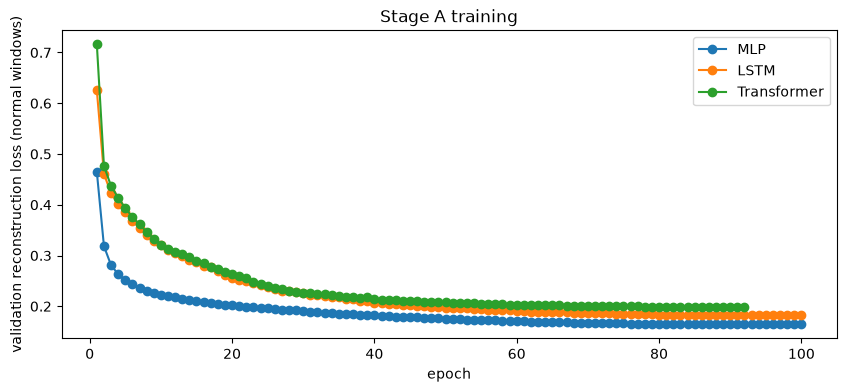

In [36]:
HIST = {name: fit_autoencoder(m, name) for name, m in A_MODELS.items()}

del TR, VA; gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

for name, h in HIST.items():
    plt.plot(h.epoch, h.val_normal, marker="o", label=name)
plt.xlabel("epoch"); plt.ylabel("validation reconstruction loss (normal windows)"); plt.legend()
plt.title("Stage A training"); plt.show()

### Puntaje, umbral y métricas

El error crece con el largo de la ventana, y el máximo sobre más ventanas suma más chances de salir alto, así que el puntaje podría medir solo cuánta actividad tiene el emisor. Probamos tres puntajes por ventana (error medio, error medio normalizado por largo y error top-3 normalizado) y dos agregaciones por emisor (máximo y media). La normalización es un z-score del log-error contra ventanas normales de entrenamiento del mismo largo. Validación elige por PR-AUC.

**Umbral:** el puntaje de validación que deja alertado al 5% de los emisores (la capacidad de revisión del equipo), aplicado igual a test. Se reportan PR-AUC, recall @5%, precision @100 y precision / recall / F1 en ese umbral, todo en test.

In [37]:
A_RES = {}
for name, m in A_MODELS.items():
    score, txerr, poolw = score_windows(m, np.arange(N))
    cands, tbl = rank_window_scores(score, txerr)
    wname, agg = tbl.iloc[0]["window score"], tbl.iloc[0]["over a sender's windows"]
    sv = to_senders(cands[wname], SETS["val"], agg).reindex(VAL_SENDERS).to_numpy()
    st = to_senders(cands[wname], SETS["test"], agg).reindex(TEST_SENDERS).to_numpy()
    A_RES[name] = dict(window_score=cands[wname], txerr=txerr, poolw=poolw, window_name=wname, agg=agg,
                       sv=sv, st=st, thr=budget_threshold(sv), cand_tbl=tbl)

rows = []
for name, r in A_RES.items():
    ev = evaluate(Y_TEST, r["st"], r["thr"])
    rows.append({"model": name, "score chosen on val": f"{r['window_name']}, {r['agg']}",
                 "val PR-AUC": average_precision(Y_VAL, r["sv"]), "test PR-AUC": ev["PR-AUC"],
                 "recall @5%": ev["recall @5%"], "P@100": ev["P@100"], "precision @thr": ev["precision @thr"],
                 "recall @thr": ev["recall @thr"], "F1 @thr": ev["F1 @thr"]})
STAGE_A_TABLE = pd.DataFrame(rows).set_index("model")
display(STAGE_A_TABLE)
print(f"Random PR-AUC on test: {Y_TEST.mean():.4f}  |  scored {N:,} windows with each model {elapsed()}")

,score chosen on val,val PR-AUC,test PR-AUC,recall @5%,P@100,precision @thr,recall @thr,F1 @thr
model,,,,,,,,
MLP,"top-3 error, length-normalized, max",0.2988,0.2426,0.4671,0.7600,0.0923,0.4630,0.1539
LSTM,"top-3 error, length-normalized, max",0.1636,0.1577,0.4280,0.5300,0.0823,0.4239,0.1379
Transformer,"top-3 error, length-normalized, max",0.1874,0.1567,0.4588,0.5200,0.0885,0.4568,0.1483


Random PR-AUC on test: 0.0094  |  scored 439,590 windows with each model [10.4 min]


**Resultados** (test; un ranking aleatorio da 0.009 de PR-AUC)

| | PR-AUC | Recall @5% | Precision @5% | Loss de validación (ventanas normales) |
|---|---|---|---|---|
| MLP | 0.243 | 0.47 | 0.09 | 0.164 |
| LSTM | 0.158 | 0.43 | 0.08 | 0.182 |
| Transformer | 0.157 | 0.46 | 0.09 | 0.199 |

- Los tres eligen el error top-3 normalizado por largo con máximo sobre ventanas, y rankean 17–26 veces mejor que al azar.
- El MLP gana, esto es algo que realmente no se esperaba. Podríamos teorizar que al ser el modelo menos robusto, encuentra más "errores" al encontrar datos no conocidos. El LSTM y el transformer pueden de cierta manera inferir estos comportamientos no vistos anteriormente  mientras que el MLP no.
- Sin etiquetas, el puntaje solo mide qué tan inusual es una ventana.
- Solo los encoders LSTM y Transformer sirven para la Etapa B, el MLP no produce un vector por transacción.

## 15. Etapa B: clasificador supervisado y ablación

Un clasificador sobre ventanas: `encoder → attention pooling nuevo → cabeza MLP → P(lavado)`. La probabilidad de un emisor es el máximo sobre sus ventanas (un emisor es positivo si alguna contiene lavado, y un promedio diluiría una ventana mala entre muchas normales), y los pesos del pooling son el heatmap de la alerta.

**Estrategia de transfer learning** (la misma para LSTM y Transformer, cada uno con su Etapa A):

| Modelo | Encoder arranca de | Se entrena | Qué evalúa |
|---|---|---|---|
| From scratch (baseline sin Etapa A) | Pesos aleatorios | Todo, solo con etiquetas | Si no se le gana, el preentrenamiento no aporta |
| Frozen (feature extraction) | Encoder de la Etapa A | Solo el pooling y la cabeza | Cuánto vale la representación de la Etapa A tal cual |
| Fine-tuned | Encoder de la Etapa A | Epoch 1: pooling y cabeza. Luego todo, con el encoder a 1/10 del learning rate | Si adaptarla a la tarea mejora lo anterior |

Hay 2,270 emisores positivos contra 206k normales, y el encoder de la Etapa A ya vio a todos los normales sin etiquetas. Frozen mide el valor puro de esa representación; fine-tuned la adapta (entrenar primero la cabeza evita que gradientes ruidosos dañen el encoder, y el learning rate bajo evita que olvide lo aprendido). Es la estrategia de la Semana 9 y del Lab-06. Todos los modelos usan los mismos datos, loss, sampling y early stopping; solo cambia el encoder y su inicialización. Se repite con LSTM y con Transformer (el MLP no produce un vector por transacción) para ver si la conclusión sobre el preentrenamiento depende de la arquitectura.

**Loss.** Solo 0.93% de las ventanas son positivas. Cada epoch usa todos los positivos y 40 negativos por positivo. Ambas son respuestas estándar al desbalance y no sabíamos cuál funcionaría mejor aquí. Comparamos **focal loss** (γ = 2, que le quita peso a lo que ya se acierta) y **cross-entropy ponderada** (positivos ×40, deshaciendo el sampling) en el LSTM fine-tuned, y el ganador en validación se usa en los 6 modelos (Lab-05).

**Modelo final.** El proyecto pide un sistema de dos etapas, así que el modelo final es el mejor sistema que sí usa la Etapa A (frozen o fine-tuned), elegido por PR-AUC de validación. Los modelos from scratch son el baseline de la ablación.

**Combinación de señales.** `final = w · pct(B) + (1 − w) · pct(A)`: percentil de la probabilidad de la Etapa B y del puntaje de la Etapa A de la misma arquitectura, con `w` elegido en validación. Sirve para ver si el puntaje de anomalía agrega algo que el clasificador no tiene. Con `w = 1`, la Etapa A no aporta nada.

In [38]:
class SequenceClassifier(nn.Module):
    """Encoder + a new attention pooling layer + MLP head -> one logit per window."""
    def __init__(self, encoder, d_model, hidden=64, dropout=0.1):
        super().__init__()
        self.encoder = encoder
        self.pool = AttentionPooling(d_model)
        self.head = nn.Sequential(nn.Linear(d_model, hidden), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden, 1))

    def forward(self, x_num, x_fmt, x_cur, valid):
        h = self.encoder(x_num, x_fmt, x_cur, valid)["h"]
        pooled, attn = self.pool(h, ~valid)
        return self.head(pooled).squeeze(-1), attn


def focal_loss(logits, y, gamma=2.0, alpha=0.5):
    bce = F.binary_cross_entropy_with_logits(logits, y, reduction="none")
    p = torch.sigmoid(logits)
    p_correct = p * y + (1 - p) * (1 - y)
    a = alpha * y + (1 - alpha) * (1 - y)
    return (a * (1 - p_correct) ** gamma * bce).mean()

def weighted_bce(logits, y, pos_weight):
    return F.binary_cross_entropy_with_logits(logits, y, pos_weight=torch.tensor(pos_weight, device=logits.device))

CFG_B = dict(lr=1e-3, enc_lr_mult=0.1, weight_decay=1e-4, batch_size=1024, max_epochs=15, patience=4,
             neg_per_pos=40, head_warmup_epochs=1, focal_gamma=2.0, focal_alpha=0.5, dropout=0.1)
ARCHS = {"lstm": "LSTM", "transformer": "Transformer"}          # key -> name of its Stage A model in A_MODELS

def build_classifier(arch, strategy):
    torch.manual_seed(SEED)
    if strategy == "scratch":                                   # random weights, same architecture as Stage A
        if arch == "lstm":
            enc = LSTMEncoder(F_NUM, N_FMT, N_CUR, MAX_LEN, CFG_A["d_model"], CFG_A["rnn_layers"], CFG_A["z_dim"],
                              CFG_A["dropout"])
        else:
            enc = TransformerEncoder(F_NUM, N_FMT, N_CUR, MAX_LEN, CFG_A["d_model"], CFG_A["n_heads"],
                                     CFG_A["n_layers"], CFG_A["d_ff"], CFG_A["z_dim"], CFG_A["dropout"])
    else:                                                       # "frozen" or "finetune": start from Stage A
        enc = copy.deepcopy(A_MODELS[ARCHS[arch]].encoder)
    clf = SequenceClassifier(enc, CFG_A["d_model"], dropout=CFG_B["dropout"])
    if strategy != "scratch":
        clf.pool.load_state_dict(A_MODELS[ARCHS[arch]].encoder.pool.state_dict())
    return clf.to(DEVICE)

print({f"{a}_{s}": f"{sum(p.numel() for p in build_classifier(a, s).parameters()):,} params"
       for a in ARCHS for s in ("scratch", "finetune")})

{'lstm_scratch': '69,411 params', 'lstm_finetune': '69,411 params', 'transformer_scratch': '86,179 params', 'transformer_finetune': '86,179 params'}


In [39]:
# data on the GPU once: Stage B training windows and validation windows
TRB = to_device(SETS["stage_b_train"])
Y_TRB = torch.from_numpy(y_seq[SETS["stage_b_train"]].astype(np.float32)).to(DEVICE)
POS_B = np.flatnonzero(y_seq[SETS["stage_b_train"]] == 1)
NEG_B = np.flatnonzero(y_seq[SETS["stage_b_train"]] == 0)
VALD = to_device(SETS["val"])

@torch.no_grad()
def predict(model, data, bs=4096):
    model.eval(); logits, attn = [], []
    for s in range(0, data[0].size(0), bs):
        lg, at = model(*[t[s:s + bs] for t in data])
        logits.append(lg.float().cpu()); attn.append(at.float().cpu())
    return torch.cat(logits).numpy(), torch.cat(attn).numpy()

def val_sender_pr_auc(window_logits):
    sv = local_to_senders(window_logits, SETS["val"], "max").reindex(VAL_SENDERS).to_numpy()
    return average_precision(Y_VAL, sv)

def set_encoder_trainable(model, trainable):
    for p in model.encoder.parameters():
        p.requires_grad = trainable

def train_classifier(arch, strategy, loss_name):
    name = f"{arch}_{strategy}"
    model = build_classifier(arch, strategy)
    pretrained = strategy != "scratch"
    enc_lr = CFG_B["lr"] * (CFG_B["enc_lr_mult"] if pretrained else 1.0)
    opt = torch.optim.AdamW([{"params": list(model.encoder.parameters()), "lr": enc_lr},
                             {"params": list(model.pool.parameters()) + list(model.head.parameters()),
                              "lr": CFG_B["lr"]}], weight_decay=CFG_B["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG_B["max_epochs"])
    rng = np.random.default_rng(SEED)
    best, best_state, bad = -1.0, None, 0

    for epoch in range(1, CFG_B["max_epochs"] + 1):
        encoder_trainable = strategy == "scratch" or (strategy == "finetune" and epoch > CFG_B["head_warmup_epochs"])
        set_encoder_trainable(model, encoder_trainable)
        model.train()
        if not encoder_trainable:
            model.encoder.eval()                      # frozen encoder: no dropout noise
        neg = rng.choice(NEG_B, size=min(len(NEG_B), CFG_B["neg_per_pos"] * len(POS_B)), replace=False)
        order = torch.from_numpy(rng.permutation(np.concatenate([POS_B, neg]))).to(DEVICE)
        run_loss = 0.0
        for s in range(0, len(order), CFG_B["batch_size"]):
            bi = order[s:s + CFG_B["batch_size"]]
            logits, _ = model(*[t[bi] for t in TRB])
            y = Y_TRB[bi]
            loss = (focal_loss(logits, y, CFG_B["focal_gamma"], CFG_B["focal_alpha"]) if loss_name == "focal"
                    else weighted_bce(logits, y, float(CFG_B["neg_per_pos"])))
            opt.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); run_loss += loss.item() * len(bi)
        sched.step()
        val_ap = val_sender_pr_auc(predict(model, VALD)[0])
        improved = val_ap > best + 1e-4
        if improved:
            best, bad = val_ap, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
        stop = bad >= CFG_B["patience"]
        if epoch == 1 or epoch % 5 == 0 or stop or epoch == CFG_B["max_epochs"]:
            print(f"  {name}/{loss_name} epoch {epoch:2d} | loss {run_loss / len(order):.4f} | "
                  f"val sender PR-AUC {val_ap:.4f} {'*' if improved else ''} {elapsed()}")
        if stop:
            break
    model.load_state_dict(best_state)
    return {"model": model, "best_val_pr_auc": best}

### Loss

Focal loss contra cross-entropy ponderada en el LSTM fine-tuned, por PR-AUC de validación.

In [40]:
B_RUNS, LOSS_RUNS = {}, {}
for loss_name in ["focal", "wbce"]:
    print(f"Training lstm_finetune with {loss_name}")
    LOSS_RUNS[loss_name] = train_classifier("lstm", "finetune", loss_name)
LOSS_B = max(LOSS_RUNS, key=lambda l: LOSS_RUNS[l]["best_val_pr_auc"])
B_RUNS["lstm_finetune"] = LOSS_RUNS[LOSS_B]
print(f"\nChosen loss (validation): {LOSS_B} | focal {LOSS_RUNS['focal']['best_val_pr_auc']:.4f} "
      f"vs weighted BCE {LOSS_RUNS['wbce']['best_val_pr_auc']:.4f}")

Training lstm_finetune with focal
  lstm_finetune/focal epoch  1 | loss 0.0254 | val sender PR-AUC 0.0667 * [10.4 min]
  lstm_finetune/focal epoch  5 | loss 0.0108 | val sender PR-AUC 0.4186 * [10.5 min]
  lstm_finetune/focal epoch 10 | loss 0.0090 | val sender PR-AUC 0.5054 * [10.6 min]
  lstm_finetune/focal epoch 15 | loss 0.0087 | val sender PR-AUC 0.5147  [10.6 min]
Training lstm_finetune with wbce
  lstm_finetune/wbce epoch  1 | loss 1.1558 | val sender PR-AUC 0.1901 * [10.6 min]
  lstm_finetune/wbce epoch  5 | loss 0.7779 | val sender PR-AUC 0.2909 * [10.7 min]
  lstm_finetune/wbce epoch 10 | loss 0.6798 | val sender PR-AUC 0.3305 * [10.8 min]
  lstm_finetune/wbce epoch 15 | loss 0.6565 | val sender PR-AUC 0.3388  [10.8 min]

Chosen loss (validation): focal | focal 0.5148 vs weighted BCE 0.3388


### Los 6 modelos

LSTM y Transformer, cada uno from scratch, frozen y fine-tuned, con el loss elegido.

In [41]:
for arch in ARCHS:
    for strategy in ["scratch", "frozen", "finetune"]:
        if f"{arch}_{strategy}" not in B_RUNS:
            print(f"Training {arch}_{strategy} with {LOSS_B}")
            B_RUNS[f"{arch}_{strategy}"] = train_classifier(arch, strategy, LOSS_B)

TESTD = to_device(SETS["test"])
B_OUT = {}
for name, run in B_RUNS.items():
    vl, va = predict(run["model"], VALD)
    tl, ta = predict(run["model"], TESTD)
    B_OUT[name] = {"val_logit": vl, "test_logit": tl, "val_attn": va, "test_attn": ta,
                   "best_val_pr_auc": run["best_val_pr_auc"]}
del TRB, Y_TRB, VALD, TESTD; gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
print(elapsed())

Training lstm_scratch with focal
  lstm_scratch/focal epoch  1 | loss 0.0153 | val sender PR-AUC 0.3091 * [10.8 min]
  lstm_scratch/focal epoch  5 | loss 0.0064 | val sender PR-AUC 0.5943 * [10.9 min]
  lstm_scratch/focal epoch 10 | loss 0.0053 | val sender PR-AUC 0.6089  [11.0 min]
Training lstm_frozen with focal
  lstm_frozen/focal epoch  1 | loss 0.0254 | val sender PR-AUC 0.0667 * [11.0 min]
  lstm_frozen/focal epoch  5 | loss 0.0124 | val sender PR-AUC 0.3195 * [11.0 min]
  lstm_frozen/focal epoch 10 | loss 0.0118 | val sender PR-AUC 0.3488 * [11.0 min]
  lstm_frozen/focal epoch 15 | loss 0.0117 | val sender PR-AUC 0.3545  [11.1 min]
Training transformer_scratch with focal
  transformer_scratch/focal epoch  1 | loss 0.0164 | val sender PR-AUC 0.3219 * [11.1 min]
  transformer_scratch/focal epoch  5 | loss 0.0068 | val sender PR-AUC 0.5720 * [11.2 min]
  transformer_scratch/focal epoch 10 | loss 0.0056 | val sender PR-AUC 0.5903 * [11.3 min]
  transformer_scratch/focal epoch 15 | l

### Resultados (test)

Cada modelo solo y mezclado con la Etapa A (columnas "+A"). `val PR-AUC` es lo que decidió la selección; lo demás es test, con el umbral que alerta al 5% en validación e intervalos bootstrap del 95%. El sistema final es el de mejor PR-AUC de validación después de mezclar.

In [42]:
def percentile_vs(ref, x):
    ref = np.sort(np.asarray(ref)); return np.searchsorted(ref, np.asarray(x), side="right") / len(ref)

def b_sender_scores(name, split):
    ids = VAL_SENDERS if split == "val" else TEST_SENDERS
    return local_to_senders(B_OUT[name][f"{split}_logit"], SETS[split], "max").reindex(ids).to_numpy()

STRAT_LABEL = {"scratch": "from scratch", "frozen": "frozen", "finetune": "fine-tuned"}
LABEL = {f"{a}_{s}": f"{ARCHS[a]} {STRAT_LABEL[s]}" for a in ARCHS for s in STRAT_LABEL}
W_GRID = np.round(np.arange(0, 1.0001, 0.1), 2)

SCORES, rows = {}, []
for name in LABEL:
    a_res = A_RES[ARCHS[name.split("_")[0]]]
    sb_v, sb_t = b_sender_scores(name, "val"), b_sender_scores(name, "test")
    pa_v, pa_t = percentile_vs(a_res["sv"], a_res["sv"]), percentile_vs(a_res["sv"], a_res["st"])
    pb_v, pb_t = percentile_vs(sb_v, sb_v), percentile_vs(sb_v, sb_t)
    val_ap = {w: average_precision(Y_VAL, w * pb_v + (1 - w) * pa_v) for w in W_GRID}
    w = max(val_ap, key=lambda k: (val_ap[k], k))                 # ties go to the larger w (less Stage A)
    bl_v, bl_t = w * pb_v + (1 - w) * pa_v, w * pb_t + (1 - w) * pa_t
    SCORES[name] = dict(B=(sb_v, sb_t), blend=(bl_v, bl_t), w=float(w), pa=(pa_v, pa_t), pb=(pb_v, pb_t),
                        w_grid=val_ap)
    ev, evb = evaluate(Y_TEST, sb_t, budget_threshold(sb_v)), evaluate(Y_TEST, bl_t)
    lo, hi = bootstrap_ci(Y_TEST, sb_t, average_precision)
    rows.append({"model": LABEL[name], "val PR-AUC": average_precision(Y_VAL, sb_v), "test PR-AUC": ev["PR-AUC"],
                 "95% CI": f"[{lo:.3f}, {hi:.3f}]", "recall @5%": ev["recall @5%"], "P@100": ev["P@100"],
                 "F1 @thr": ev["F1 @thr"], "w": w, "val PR-AUC (+A)": val_ap[w],
                 "test PR-AUC (+A)": evb["PR-AUC"], "recall @5% (+A)": evb["recall @5%"]})
STAGE_B_TABLE = pd.DataFrame(rows).set_index("model")
display(STAGE_B_TABLE)

# final system: best validation PR-AUC after blending
# canonical model: the best system that actually uses Stage A (the project is a two-stage design).
# The from-scratch models are the baseline of the ablation, not candidates for the final system.
FINAL_B = max([n for n in SCORES if not n.endswith("_scratch")], key=lambda n: STAGE_B_TABLE.loc[LABEL[n], "val PR-AUC (+A)"])
FINAL_ARCH = ARCHS[FINAL_B.split("_")[0]]
W_BLEND = SCORES[FINAL_B]["w"]
SA_VAL, SA_TEST = A_RES[FINAL_ARCH]["sv"], A_RES[FINAL_ARCH]["st"]
SB_VAL, SB_TEST = SCORES[FINAL_B]["B"]
PA_VAL, PA_TEST = SCORES[FINAL_B]["pa"]
PB_VAL, PB_TEST = SCORES[FINAL_B]["pb"]
FINAL_VAL, FINAL_TEST = SCORES[FINAL_B]["blend"]
THR_FINAL = budget_threshold(FINAL_VAL)
TXERR_A, POOLW_A = A_RES[FINAL_ARCH]["txerr"], A_RES[FINAL_ARCH]["poolw"]
A_WINDOW_NAME, A_AGG = A_RES[FINAL_ARCH]["window_name"], A_RES[FINAL_ARCH]["agg"]
FINAL_LABEL = f"Final: {LABEL[FINAL_B]} + Stage A (w = {W_BLEND})"
print(f"Final system: {LABEL[FINAL_B]} + {FINAL_ARCH} Stage A | w = {W_BLEND} | random PR-AUC {Y_TEST.mean():.4f}")
print(f"Threshold {THR_FINAL:.4f} (top 5% on validation) -> alerts {(FINAL_VAL >= THR_FINAL).mean():.1%} of "
      f"validation and {(FINAL_TEST >= THR_FINAL).mean():.1%} of test senders")

,val PR-AUC,test PR-AUC,95% CI,recall @5%,P@100,F1 @thr,w,val PR-AUC (+A),test PR-AUC (+A),recall @5% (+A)
model,,,,,,,,,,
LSTM from scratch,0.6123,0.5821,"[0.542, 0.625]",0.7901,1.0000,0.2500,1.0000,0.6123,0.5821,0.7901
LSTM frozen,0.3545,0.3213,"[0.283, 0.360]",0.5350,0.8700,0.1687,0.9000,0.3600,0.3292,0.5041
LSTM fine-tuned,0.5148,0.4971,"[0.457, 0.539]",0.6996,1.0000,0.2181,1.0000,0.5148,0.4971,0.6996
Transformer from scratch,0.5938,0.5584,"[0.517, 0.598]",0.7881,1.0000,0.2506,1.0000,0.5938,0.5583,0.7881
Transformer frozen,0.5494,0.5043,"[0.460, 0.555]",0.7305,0.9600,0.2343,1.0000,0.5494,0.5043,0.7305
Transformer fine-tuned,0.6001,0.5722,"[0.531, 0.614]",0.7840,1.0000,0.2489,1.0000,0.6001,0.5722,0.7840


Final system: Transformer fine-tuned + Transformer Stage A | w = 1.0 | random PR-AUC 0.0094
Threshold 0.9500 (top 5% on validation) -> alerts 5.0% of validation and 5.0% of test senders


In [43]:
def paired_bootstrap(y, s1, s2, fn, n_boot=500, seed=SEED):
    """Difference fn(s1) - fn(s2) on the same resampled senders."""
    rng = np.random.default_rng(seed); diffs = []
    for _ in range(n_boot):
        i = rng.integers(0, len(y), len(y))
        diffs.append(fn(y[i], s1[i]) - fn(y[i], s2[i]))
    diffs = np.array(diffs)
    return diffs.mean(), np.percentile(diffs, 2.5), np.percentile(diffs, 97.5)

best_scratch = max(["lstm_scratch", "transformer_scratch"], key=lambda n: B_OUT[n]["best_val_pr_auc"])
comparisons = ([(LABEL[f"{a}_{s}"], SCORES[f"{a}_{s}"]["B"][1], LABEL[f"{a}_scratch"], SCORES[f"{a}_scratch"]["B"][1])
                for a in ARCHS for s in ("frozen", "finetune")] +
               [(LABEL["lstm_scratch"], SCORES["lstm_scratch"]["B"][1],
                 LABEL["transformer_scratch"], SCORES["transformer_scratch"]["B"][1]),
                (FINAL_LABEL, FINAL_TEST, LABEL["lstm_scratch"], SCORES["lstm_scratch"]["B"][1]),
                (FINAL_LABEL, FINAL_TEST, LABEL["transformer_scratch"], SCORES["transformer_scratch"]["B"][1])])
print("Test PR-AUC differences (paired bootstrap, 95% CI):")
for name_a, sa, name_b, sb in comparisons:
    m, lo, hi = paired_bootstrap(Y_TEST, sa, sb, average_precision)
    verdict = "better" if lo > 0 else "worse" if hi < 0 else "within noise"
    print(f"  {name_a} vs {name_b}: {m:+.4f} [{lo:+.4f}, {hi:+.4f}] -> {verdict}")

Test PR-AUC differences (paired bootstrap, 95% CI):
  LSTM frozen vs LSTM from scratch: -0.2612 [-0.2979, -0.2245] -> worse
  LSTM fine-tuned vs LSTM from scratch: -0.0853 [-0.1078, -0.0626] -> worse
  Transformer frozen vs Transformer from scratch: -0.0544 [-0.0795, -0.0311] -> worse
  Transformer fine-tuned vs Transformer from scratch: +0.0140 [-0.0015, +0.0299] -> within noise
  LSTM from scratch vs Transformer from scratch: +0.0245 [+0.0076, +0.0418] -> better
  Final: Transformer fine-tuned + Stage A (w = 1.0) vs LSTM from scratch: -0.0105 [-0.0268, +0.0065] -> within noise
  Final: Transformer fine-tuned + Stage A (w = 1.0) vs Transformer from scratch: +0.0140 [-0.0014, +0.0299] -> within noise


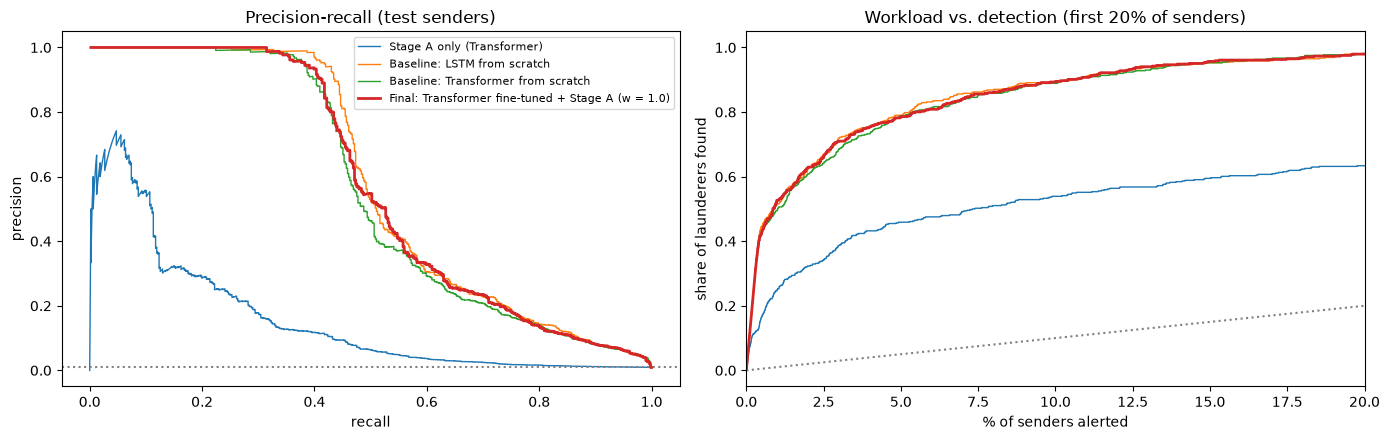

,positives,Stage A only (Transformer),Baseline: LSTM from scratch,Baseline: Transformer from scratch,Final: Transformer fine-tuned + Stage A (w = 1.0)
pattern,,,,,
FAN-OUT,3,1.0000,1.0000,1.0000,1.0000
SCATTER-GATHER,43,0.6977,0.9767,0.9767,0.9535
STACK,58,0.6552,0.9138,0.8621,0.9483
CYCLE,35,0.6571,0.9429,0.9429,0.9429
RANDOM,29,0.5862,0.9310,0.8621,0.9310
FAN-IN,51,0.7451,0.9020,0.9020,0.9020
GATHER-SCATTER,42,0.6429,0.7857,0.7857,0.7857
BIPARTITE,30,0.6333,0.8667,0.8333,0.7667
(no typology),195,0.1436,0.6205,0.6462,0.6154


In [44]:
MODELS = {f"Stage A only ({FINAL_ARCH})": (SA_VAL, SA_TEST),
          f"Baseline: {LABEL['lstm_scratch']}": SCORES["lstm_scratch"]["B"],
          f"Baseline: {LABEL['transformer_scratch']}": SCORES["transformer_scratch"]["B"],
          FINAL_LABEL: (FINAL_VAL, FINAL_TEST)}

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for label, (sv, st) in MODELS.items():
    o = np.argsort(-st, kind="mergesort"); ys = Y_TEST[o]
    prec = np.cumsum(ys) / np.arange(1, len(ys) + 1); rec = np.cumsum(ys) / ys.sum()
    ax[0].plot(rec, prec, label=label, lw=2 if label == FINAL_LABEL else 1)
    ax[1].plot(np.arange(1, len(ys) + 1) / len(ys) * 100, rec, lw=2 if label == FINAL_LABEL else 1)
ax[0].axhline(Y_TEST.mean(), color="gray", ls=":"); ax[0].set_xlabel("recall"); ax[0].set_ylabel("precision")
ax[0].set_title("Precision-recall (test senders)"); ax[0].legend(fontsize=8)
ax[1].plot([0, 100], [0, 1], color="gray", ls=":"); ax[1].set_xlim(0, 20)
ax[1].set_xlabel("% of senders alerted"); ax[1].set_ylabel("share of launderers found")
ax[1].set_title("Workload vs. detection (first 20% of senders)")
plt.tight_layout(); plt.show()

# which typologies does each model find when 5% of test senders are alerted?
typ = senders.loc[TEST_SENDERS, ["label", "pattern", "has_tail"]].copy()
typ["pattern"] = typ["pattern"].fillna("(no typology)")
for label, (_, st) in MODELS.items():
    typ[label] = alert_top(st, 0.05)
pos = typ[typ.label == 1]
by_typ = pos.groupby("pattern")[list(MODELS)].mean()
by_typ.insert(0, "positives", pos.groupby("pattern").size())
display(by_typ.sort_values(FINAL_LABEL, ascending=False))

**Resultados** (test; un ranking aleatorio da 0.009 de PR-AUC)

| Modelo | PR-AUC val | PR-AUC test [IC 95%] | Recall @5% | Precision @100 | Precision @5% |
|---|---|---|---|---|---|
| LSTM from scratch | 0.612 | 0.582 [0.542, 0.625] | 0.79 | 1.00 | 0.15 |
| LSTM frozen | 0.354 | 0.321 [0.283, 0.360] | 0.54 | 0.87 | 0.10 |
| LSTM fine-tuned | 0.515 | 0.497 [0.457, 0.539] | 0.70 | 1.00 | 0.13 |
| Transformer from scratch | 0.594 | 0.558 [0.517, 0.598] | 0.79 | 1.00 | 0.15 |
| Transformer frozen | 0.549 | 0.504 [0.460, 0.555] | 0.73 | 0.96 | 0.14 |
| **Transformer fine-tuned (final)** | **0.600** | **0.572 [0.531, 0.614]** | **0.78** | **1.00** | **0.15** |

El modelo final es el Transformer fine-tuned, con `w = 1`. La Etapa A inicializa el encoder, pero su puntaje no entra a la predicción. La mezcla con la Etapa A no aporta, porque validación elige `w = 1` en 5 de los 6 modelos; en LSTM frozen elige `w = 0.9`, y el recall al 5% baja de 0.54 a 0.50. En términos de negocio, con el modelo final se alertan ~2,575 emisores (5%) y se encuentra el 78% de los lavadores. De esas alertas ~15% son reales (los sistemas por reglas rondan 1–5%), y las 100 más altas lo son todas. Entre los emisores normales se alerta al 4.3%.

**Diferencias de PR-AUC en test** (bootstrap pareado, IC 95%)

| Comparación | Diferencia | Veredicto |
|---|---|---|
| LSTM frozen − LSTM from scratch | −0.261 [−0.298, −0.225] | peor |
| LSTM fine-tuned − LSTM from scratch | −0.085 [−0.108, −0.063] | peor |
| Transformer frozen − Transformer from scratch | −0.054 [−0.080, −0.031] | peor |
| Transformer fine-tuned − Transformer from scratch | +0.014 [−0.002, +0.030] | dentro del ruido |
| LSTM from scratch − Transformer from scratch | +0.025 [+0.008, +0.042] | mejor |
| **Final (Transformer fine-tuned) − LSTM from scratch** | −0.011 [−0.027, +0.007] | dentro del ruido |

El transfer no mejora de forma consistente. Con el Transformer, fine-tuned queda por encima de desde cero (+0.014), pero dentro del ruido; con el LSTM es claramente peor (−0.085). Frozen es peor en ambas arquitecturas. Además, el modelo final empata con el mejor baseline: −0.011 contra el LSTM from scratch, con un intervalo que incluye el 0.

**Por tipología** (recall con el 5% de emisores alertado por cada modelo)

| Tipología | Positivos | Etapa A (Transformer) | LSTM from scratch | Transformer from scratch | Transformer fine-tuned (final) |
|---|---|---|---|---|---|
| FAN-OUT | 3 | 1.00 | 1.00 | 1.00 | 1.00 |
| SCATTER-GATHER | 43 | 0.70 | 0.98 | 0.98 | 0.95 |
| CYCLE | 35 | 0.66 | 0.94 | 0.94 | 0.94 |
| RANDOM | 29 | 0.59 | 0.93 | 0.86 | 0.93 |
| STACK | 58 | 0.66 | 0.91 | 0.86 | 0.95 |
| FAN-IN | 51 | 0.75 | 0.90 | 0.90 | 0.90 |
| BIPARTITE | 30 | 0.63 | 0.87 | 0.83 | 0.77 |
| GATHER-SCATTER | 42 | 0.64 | 0.79 | 0.79 | 0.79 |
| Sin tipología | 195 | 0.14 | 0.62 | 0.65 | 0.62 |
| **Total** | **486** | **0.46** | **0.79** | **0.79** | **0.78** |

Las tipologías nombradas se detectan bien (77–100% en el modelo final); lo que se escapa es el lavado sin tipología (62%), que es el 40% de los positivos. La Etapa A sola casi no lo ve (14%). Los positivos de la cola se detectan **más** que el resto (93% contra 76%). El modelo no ve tiempo absoluto, pero esta diferencia es una señal a vigilar de un posible artefacto del simulador.

### Análisis y ganador

**Calidad de los resultados.** Contra el azar, buenos. El modelo final llega a 0.57 de PR-AUC (61 veces la tasa base) y, alertando al 5% de los emisores, encuentra el 78% de los lavadores con ~15% de alertas reales y las 100 más altas correctas contra 1–5% en sistemas por reglas. Aun así, ~85% de las alertas siguen siendo falsos positivos, y los datos son sintéticos así que esa precision no se traslada tal cual a remesas reales. La Etapa A sola es mucho más débil: 0.16–0.24 de PR-AUC y 43–47% de recall al 5%.

**Preentrenamiento.** El resultado es inconsistente entre arquitecturas. Con el Transformer, fine-tuned queda ligeramente por encima de desde cero (0.572 contra 0.558), aunque dentro del ruido. Con el LSTM es claramente peor que desde cero (0.497 contra 0.582). Si preentrenar aportara algo general, esperaríamos el mismo signo en las dos. Lo más probable es que no haya un efecto real de la Etapa A y que las diferencias vengan de ruido (una sola semilla, y resultados que cambian un poco entre corridas) y de cómo se optimiza cada encoder. Una explicación posible, sin verificar, es que reconstruir lo normal no obliga al encoder a representar lo que distingue al lavado. Lo único que se sostiene es que congelar el encoder pierde siempre, y que entrenar con etiquetas desde cero ya es muy fuerte.

**Modelo final: Transformer fine-tuned.** En métricas empata con el LSTM from scratch (PR-AUC de test 0.572 contra 0.582, la diferencia se encuentra dentro del rango de ruido; recall al 5% 0.78 contra 0.79; precision @100 de 1.00 en ambos), que tiene un PR-AUC de validación apenas mayor (0.612 contra 0.600). Elegimos el Transformer fine-tuned porque es el mejor sistema que usa la Etapa A, que es lo que pide el proyecto, y porque su atención sí señala el lavado (sección 16). La conclusión honesta es que el sistema de dos etapas **no supera** al clasificador entrenado desde cero: lo iguala.

# Componente 3: Análisis e interpretabilidad

## 16. Interpretabilidad

El attention pooling del modelo final da un peso por transacción (suman 1), que es el heatmap de la alerta. Como el dataset marca qué transacciones son lavado, medimos si la atención cae sobre ellas y la comparamos con el error de reconstrucción por transacción de la Etapa A. Los pesos de atención no son automáticamente una explicación fiel.

In [45]:
TEST_IDX = SETS["test"]
ATT_TEST = B_OUT[FINAL_B]["test_attn"]
win_tbl = pd.DataFrame({"window": TEST_IDX, "sender": SENDER_OF[TEST_IDX], "logit": B_OUT[FINAL_B]["test_logit"]})
best_window = win_tbl.loc[win_tbl.groupby("sender")["logit"].idxmax()].set_index("sender")["window"]

final_tbl = pd.DataFrame({"label": Y_TEST, "final": FINAL_TEST, "classifier pct": PB_TEST, "anomaly pct": PA_TEST},
                         index=TEST_SENDERS)
final_tbl["alert"] = FINAL_TEST >= THR_FINAL        # the 5% budget cutoff chosen on validation
final_tbl["best window"] = best_window.reindex(final_tbl.index).astype(int)
final_tbl["rank pct"] = percentile_vs(FINAL_TEST, FINAL_TEST)

def local(g):
    return int(np.searchsorted(TEST_IDX, g))

hit_rows = []
for sid, r in final_tbl[(final_tbl.label == 1) & final_tbl.alert].iterrows():
    g = int(r["best window"]); n = int(LEN[g]); yt = Y_TX[g, :n]
    if yt.sum() == 0 or n < 2:
        continue
    att, er = ATT_TEST[local(g), :n], TXERR_A[g, :n]
    hit_rows.append({"length": n, "top attention is laundering": yt[att.argmax()] == 1,
                     "top Stage A error is laundering": yt[er.argmax()] == 1,
                     "random pick is laundering": yt.mean(),
                     "attention on laundering tx": att[yt == 1].sum(), "laundering share of window": yt.mean()})
HIT = pd.DataFrame(hit_rows)
if len(HIT):
    display(HIT.drop(columns="length").mean().to_frame("average over detected positives"))
    print(f"n = {len(HIT)} detected positive senders whose top window contains laundering")
    print(f"Attention puts {HIT['attention on laundering tx'].mean():.0%} of its weight on laundering transactions "
          f"that make up {HIT['laundering share of window'].mean():.0%} of those windows.")

,average over detected positives
top attention is laundering,0.6745
top Stage A error is laundering,0.7244
random pick is laundering,0.2324
attention on laundering tx,0.6423
laundering share of window,0.2324


n = 381 detected positive senders whose top window contains laundering
Attention puts 64% of its weight on laundering transactions that make up 23% of those windows.


**Resultados**

En los 381 emisores positivos detectados cuya mejor ventana contiene lavado, la transacción con más atención del modelo final es de lavado el **67%** de las veces (elegir al azar: 23%). La atención pone 64% de su peso en transacciones de lavado, que son el 23% de esas ventanas. La transacción con mayor error de reconstrucción de la Etapa A es de lavado el **72%** de las veces. Las dos señales funcionan y son parecidas: la atención del modelo final es una explicación usable, y el error de la Etapa A es una segunda señal independiente.

### Casos de estudio

Tres detecciones, un falso positivo y un falso negativo, elegidos automáticamente en test: los 3 verdaderos positivos mejor rankeados, el falso positivo mejor rankeado y el positivo con tipología conocida peor rankeado. Cada caso muestra el heatmap de atención, el error de la Etapa A, las transacciones y una explicación generada.

In [46]:
def load_table(name):
    p = os.path.join(OUT_DIR, name + ".parquet")
    return pd.read_parquet(p) if os.path.exists(p) else pd.read_csv(os.path.join(OUT_DIR, name + ".csv"), parse_dates=["ts"])
TX_VIEW = load_table("eval_transactions")

def raw_feature(g, f):
    v = X_num[g, :LEN[g], NUM_FEATURES.index(f)].astype(np.float64)
    if f in NORM:
        v = v * NORM[f]["std"] + NORM[f]["mean"]
    return v

def case_table(sid):
    r = final_tbl.loc[sid]; g = int(r["best window"]); n = int(LEN[g])
    tx = TX_VIEW[TX_VIEW["seq"] == g].sort_values("pos").reset_index(drop=True)
    tx["attention"] = ATT_TEST[local(g), :n]
    tx["stage A error"] = TXERR_A[g, :n]
    tx["gap min"] = np.expm1(raw_feature(g, "log_gap")).clip(min=0)
    tx["new receiver"] = raw_feature(g, "is_new_receiver").round().astype(int)
    tx["receiver senders so far"] = np.expm1(raw_feature(g, "log_recv_senders")).round().astype(int)
    return r, g, tx

def explain(sid):
    r, g, tx = case_table(sid)
    top = tx.sort_values("attention", ascending=False).head(3)
    parts = []
    for _, t in top.iterrows():
        d = f"#{int(t['pos']) + 1} ({t['amt_usd']:,.0f} USD by {t['pay_format']}"
        d += ", to a new receiver" if t["new receiver"] else ", to a receiver it had paid before"
        if t["receiver senders so far"] >= 10:
            d += f" that had already received money from {int(t['receiver senders so far'])} different senders"
        if t["pos"] > 0 and t["gap min"] < 60:
            d += f", {t['gap min']:.0f} minutes after the previous payment"
        parts.append(d + ")")
    span_h = (tx["ts"].max() - tx["ts"].min()).total_seconds() / 3600
    top_share = 1 - r["rank pct"]
    return (f"Sender {senders.loc[sid, 'sender_name']} is in the top {max(top_share, 1 / len(final_tbl)):.1%} of senders by risk "
            f"(classifier percentile {r['classifier pct']:.0%}, anomaly percentile {r['anomaly pct']:.0%}). "
            f"Its riskiest window has {len(tx)} transactions over {span_h:.0f} hours; "
            f"{(tx['pay_format'] == 'ACH').mean():.0%} are ACH and {int(tx['new receiver'].sum())} go to new receivers. "
            f"The model's attention concentrates on transactions " + "; ".join(parts) +
            f", which together receive {top['attention'].sum():.0%} of the attention.")

def show_case(sid, title):
    r, g, tx = case_table(sid)
    print(f"{title} | label {int(r['label'])} | final score {r['final']:.3f} | alerted: {bool(r['alert'])}")
    print(explain(sid))
    colors = np.where(tx["is_laundering"] == 1, "red", "tab:blue")
    fig, ax = plt.subplots(2, 1, figsize=(12, 3.8), sharex=True)
    ax[0].bar(tx["pos"] + 1, tx["attention"], color=colors); ax[0].set_ylabel("Stage B attention")
    ax[0].set_title(f"{senders.loc[sid, 'sender_name']} — red = true laundering transaction")
    ax[1].bar(tx["pos"] + 1, tx["stage A error"], color=colors); ax[1].set_ylabel("Stage A error")
    ax[1].set_xlabel("transaction in window")
    plt.tight_layout(); plt.show()
    # only the rows that matter: the laundering transactions and the 5 most attended (the full window is in the plot)
    keep = tx[(tx["is_laundering"] == 1) | tx.index.isin(tx["attention"].nlargest(5).index)].head(15)
    display(keep[["pos", "amt_usd", "pay_format", "new receiver", "receiver senders so far", "gap min", "attention",
                  "stage A error", "is_laundering", "pattern"]]
              .assign(pos=lambda d: d["pos"] + 1).round({"amt_usd": 0, "gap min": 1, "attention": 3, "stage A error": 3}))
    print(f"(showing {len(keep)} of {len(tx)} transactions)")

ranked = final_tbl.sort_values("final", ascending=False)
long_enough = ranked["best window"].map(lambda g: LEN[g] >= 5)
has_laund = ranked["best window"].map(lambda g: Y_TX[g].sum() > 0)
CASES = []
CASES += [(sid, f"True positive #{i + 1}") for i, sid in enumerate(ranked[(ranked.label == 1) & long_enough & has_laund].index[:3])]
CASES += [(sid, "False positive") for sid in ranked[(ranked.label == 0) & long_enough].index[:1]]
fn_pool = ranked[(ranked.label == 1) & long_enough & has_laund]
fn_pool = fn_pool[senders.loc[fn_pool.index, "pattern"].notna().to_numpy()]
CASES += [(sid, "False negative") for sid in fn_pool.index[-1:]]


True positive #1 | label 1 | final score 1.000 | alerted: True
Sender 210185_80C46DE50 is in the top 0.0% of senders by risk (classifier percentile 100%, anomaly percentile 99%). Its riskiest window has 5 transactions over 278 hours; 60% are ACH and 3 go to new receivers. The model's attention concentrates on transactions #5 (18,515 USD by ACH, to a new receiver that had already received money from 17 different senders, 0 minutes after the previous payment); #2 (8,103 USD by Reinvestment, to a receiver it had paid before); #4 (18,515 USD by ACH, to a receiver it had paid before), which together receive 100% of the attention.


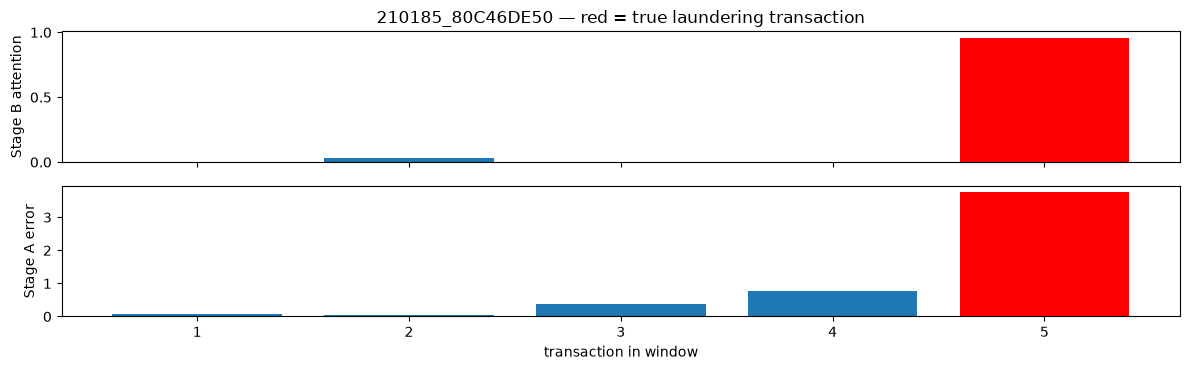

,pos,amt_usd,pay_format,new receiver,receiver senders so far,gap min,attention,stage A error,is_laundering,pattern
0,1,14.0000,Reinvestment,1,1,0.0000,0.0020,0.0680,0,NaN
1,2,"8,103.0000",Reinvestment,0,1,"1,202.0000",0.0330,0.0500,0,NaN
2,3,"1,372.0000",ACH,1,38,"8,824.0000",0.0010,0.3730,0,NaN
3,4,"18,515.0000",ACH,0,2,"6,661.0000",0.0030,0.7770,0,NaN
4,5,"18,515.0000",ACH,1,17,0.0000,0.9600,3.7660,1,FAN-IN


(showing 5 of 5 transactions)


In [47]:
show_case(*CASES[0])

**Verdadero positivo 1 (fan-in).** Ventana de 5 transacciones; solo la última (#5, 18,515 USD por ACH) es de lavado. La atención (96%) cae en ella, un pago a un receptor nuevo que ya había recibido de 17 emisores distintos, hecho al mismo tiempo que el anterior. Es justo el patrón de fan-in.

True positive #2 | label 1 | final score 1.000 | alerted: True
Sender 19318_80AF1F630 is in the top 0.0% of senders by risk (classifier percentile 100%, anomaly percentile 100%). Its riskiest window has 5 transactions over 252 hours; 60% are ACH and 3 go to new receivers. The model's attention concentrates on transactions #5 (19,031 USD by ACH, to a new receiver that had already received money from 12 different senders, 0 minutes after the previous payment); #2 (31,767 USD by Reinvestment, to a receiver it had paid before); #4 (19,031 USD by ACH, to a receiver it had paid before), which together receive 99% of the attention.


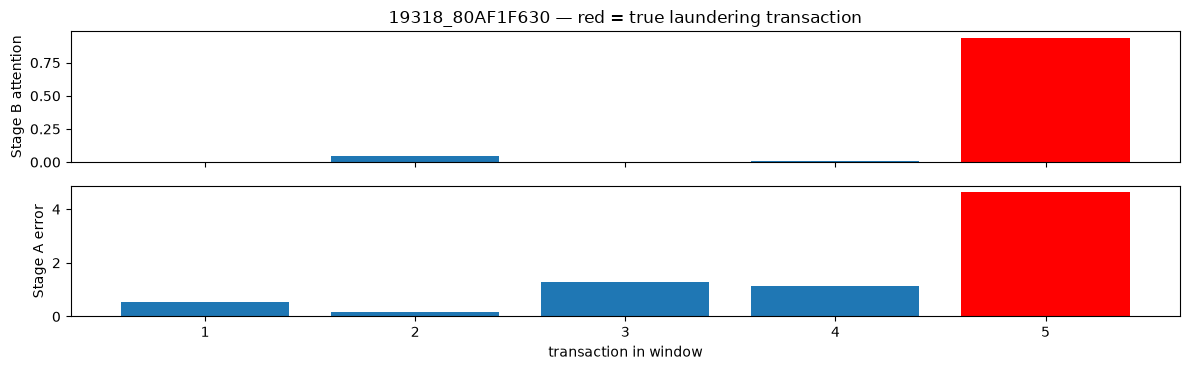

,pos,amt_usd,pay_format,new receiver,receiver senders so far,gap min,attention,stage A error,is_laundering,pattern
0,1,25.0000,Reinvestment,1,1,0.0000,0.0040,0.5530,0,NaN
1,2,"31,767.0000",Reinvestment,0,1,702.0000,0.0490,0.1500,0,NaN
2,3,"2,951.0000",ACH,1,44,"2,282.0000",0.0020,1.2800,0,NaN
3,4,"19,031.0000",ACH,0,1,"12,128.0000",0.0060,1.1330,0,NaN
4,5,"19,031.0000",ACH,1,12,0.0000,0.9400,4.6410,1,FAN-IN


(showing 5 of 5 transactions)


In [48]:
show_case(*CASES[1])

**Verdadero positivo 2 (fan-in).** Mismo patrón: la #5 (19,031 USD por ACH, a un receptor nuevo que ya había recibido de 12 emisores) concentra 94% de la atención.

True positive #3 | label 1 | final score 1.000 | alerted: True
Sender 23833_80197C0D0 is in the top 0.0% of senders by risk (classifier percentile 100%, anomaly percentile 92%). Its riskiest window has 32 transactions over 203 hours; 22% are ACH and 1 go to new receivers. The model's attention concentrates on transactions #32 (8,334 USD by ACH, to a new receiver, 0 minutes after the previous payment); #2 (839 USD by Cheque, to a receiver it had paid before, 10 minutes after the previous payment); #3 (2,835 USD by ACH, to a receiver it had paid before), which together receive 98% of the attention.


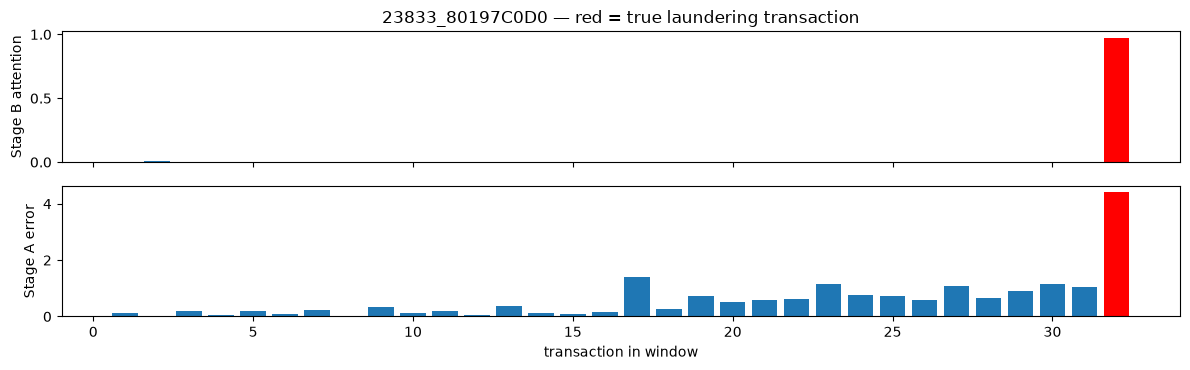

,pos,amt_usd,pay_format,new receiver,receiver senders so far,gap min,attention,stage A error,is_laundering,pattern
1,2,839.0000,Cheque,0,3,10.0000,0.0050,0.0160,0,NaN
2,3,"2,835.0000",ACH,0,3,797.0000,0.0020,0.1980,0,NaN
20,21,"2,835.0000",ACH,0,4,"1,082.0000",0.0020,0.5950,0,NaN
22,23,"20,755.0000",Credit Card,0,4,6.0000,0.0020,1.1390,0,NaN
31,32,"8,334.0000",ACH,1,8,0.0000,0.9750,4.4190,1,FAN-IN


(showing 5 of 32 transactions)


In [49]:
show_case(*CASES[2])

**Verdadero positivo 3 (fan-in).** Ventana de 32 transacciones donde solo la última (#32, 8,334 USD por ACH, a un receptor nuevo) es de lavado (solo 22% de la ventana es ACH). La atención pone 98% en ella.

False positive | label 0 | final score 0.996 | alerted: True
Sender 32008_800CC97A0 is in the top 0.3% of senders by risk (classifier percentile 100%, anomaly percentile 88%). Its riskiest window has 6 transactions over 184 hours; 100% are ACH and 3 go to new receivers. The model's attention concentrates on transactions #4 (2,318 USD by ACH, to a new receiver, 0 minutes after the previous payment); #2 (0 USD by ACH, to a new receiver, 0 minutes after the previous payment); #6 (2,318 USD by ACH, to a receiver it had paid before, 0 minutes after the previous payment), which together receive 98% of the attention.


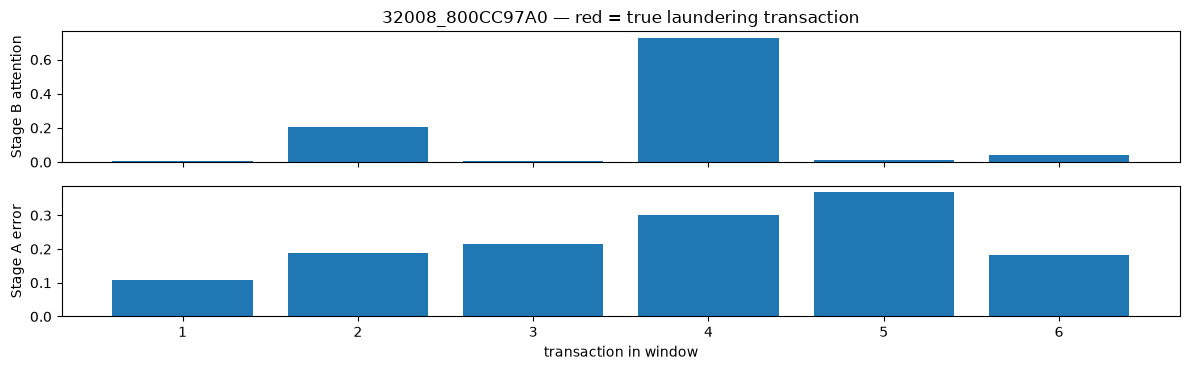

,pos,amt_usd,pay_format,new receiver,receiver senders so far,gap min,attention,stage A error,is_laundering,pattern
1,2,0.0000,ACH,1,2,0.0000,0.2030,0.1880,0,NaN
2,3,"2,318.0000",ACH,0,1,"1,214.0000",0.0080,0.2140,0,NaN
3,4,"2,318.0000",ACH,1,3,0.0000,0.7290,0.3020,0,NaN
4,5,"2,318.0000",ACH,0,1,"9,823.0000",0.0120,0.3690,0,NaN
5,6,"2,318.0000",ACH,0,3,0.0000,0.0440,0.1830,0,NaN


(showing 5 of 6 transactions)


In [50]:
show_case(*CASES[3])

**Falso positivo.** Un emisor legítimo con 6 pagos por ACH, dos de exactamente 2,318 USD, sin separación en el tiempo, y uno de 0 USD. Se parece a un fraccionamiento de montos; el modelo no tiene forma de saber que es legítimo.

False negative | label 1 | final score 0.819 | alerted: False
Sender 1267_8047B6D80 is in the top 17.9% of senders by risk (classifier percentile 82%, anomaly percentile 99%). Its riskiest window has 31 transactions over 192 hours; 29% are ACH and 3 go to new receivers. The model's attention concentrates on transactions #2 (8,809 USD by ACH, to a new receiver, 0 minutes after the previous payment); #22 (87,086 USD by Cheque, to a receiver it had paid before, 1 minutes after the previous payment); #1 (8,809 USD by ACH, to a new receiver), which together receive 73% of the attention.


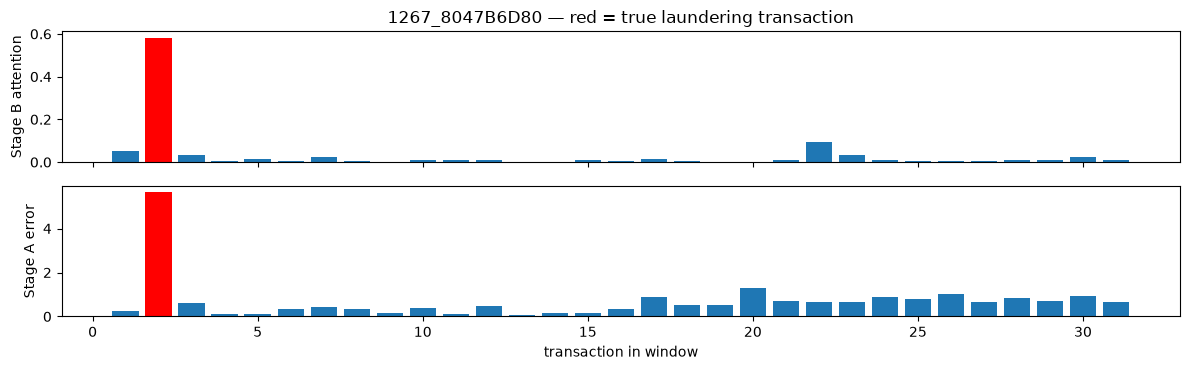

,pos,amt_usd,pay_format,new receiver,receiver senders so far,gap min,attention,stage A error,is_laundering,pattern
0,1,"8,809.0000",ACH,1,1,0.0000,0.0540,0.2690,0,NaN
1,2,"8,809.0000",ACH,1,2,0.0000,0.5830,5.6630,1,BIPARTITE
2,3,"87,086.0000",Cheque,1,2,518.0000,0.0320,0.6360,0,NaN
21,22,"87,086.0000",Cheque,0,3,1.0000,0.0950,0.6630,0,NaN
22,23,"10,957.0000",Credit Card,0,3,1.0000,0.0330,0.6770,0,NaN


(showing 5 of 31 transactions)


In [51]:
show_case(*CASES[4])

**Falso negativo (bipartite).** La transacción de lavado es la #2 (8,809 USD por ACH a un receptor nuevo) y la atención sí la encuentra (58%), pero el clasificador lo dejó en el percentil 82, fuera del 5% alertado. La Etapa A lo ubicó en el percentil 99 de anomalía, pero con `w = 1` esa señal no entra a la decisión.

In [52]:
for name, m in A_MODELS.items():
    torch.save({"state_dict": m.state_dict(), "cfg": CFG_A, "threshold": A_RES[name]["thr"],
                "window_score": A_RES[name]["window_name"], "agg": A_RES[name]["agg"]},
               os.path.join(OUT_DIR, f"stage_a_{name.lower()}.pt"))
    A_RES[name]["cand_tbl"].to_csv(os.path.join(OUT_DIR, f"stage_a_{name.lower()}_scoring_candidates.csv"), index=False)
    HIST[name].to_csv(os.path.join(OUT_DIR, f"stage_a_{name.lower()}_history.csv"), index=False)
STAGE_A_TABLE.to_csv(os.path.join(OUT_DIR, "stage_a_results.csv"))
STAGE_B_TABLE.to_csv(os.path.join(OUT_DIR, "ablation_results.csv"))
np.save(os.path.join(OUT_DIR, "window_score_a.npy"), A_RES[FINAL_ARCH]["window_score"].astype(np.float32))
np.save(os.path.join(OUT_DIR, "txerr_a.npy"), TXERR_A.astype(np.float32))
np.save(os.path.join(OUT_DIR, "poolw_a.npy"), POOLW_A.astype(np.float32))

torch.save({"state_dict": B_RUNS[FINAL_B]["model"].state_dict(), "strategy": FINAL_B, "arch": FINAL_ARCH,
            "loss": LOSS_B, "cfg_a": CFG_A, "cfg_b": CFG_B}, os.path.join(OUT_DIR, "stage_b.pt"))
final_tbl.assign(sender_name=senders.loc[final_tbl.index, "sender_name"]).reset_index(names="sender") \
         .pipe(save_table, "final_test_senders")
np.save(os.path.join(OUT_DIR, "stage_b_test_attention.npy"), ATT_TEST.astype(np.float32))
with open(os.path.join(OUT_DIR, "final_system.json"), "w") as f:
    json.dump({"stage_b_strategy": FINAL_B, "arch": FINAL_ARCH, "loss": LOSS_B, "blend_w": W_BLEND,
               "threshold": THR_FINAL, "stage_a_window_score": A_WINDOW_NAME, "stage_a_agg": A_AGG,
               "val_reference_stage_a": np.sort(SA_VAL).tolist()[::50],
               "val_reference_stage_b": np.sort(SB_VAL).tolist()[::50]}, f)
print(sorted(os.listdir(OUT_DIR)))
print(f"Total runtime {elapsed()}")

['MASK.npy', 'TX_ID.npy', 'X_cur.npy', 'X_fmt.npy', 'X_num.npy', 'Y_TX.npy', 'ablation_results.csv', 'eval_transactions.parquet', 'final_system.json', 'final_test_senders.parquet', 'idx_stage_a_train.npy', 'idx_stage_b_train.npy', 'idx_test.npy', 'idx_val.npy', 'meta.json', 'poolw_a.npy', 'senders.parquet', 'stage_a.pt', 'stage_a_history.csv', 'stage_a_lstm.pt', 'stage_a_lstm_history.csv', 'stage_a_lstm_scoring_candidates.csv', 'stage_a_mlp.pt', 'stage_a_mlp_history.csv', 'stage_a_mlp_scoring_candidates.csv', 'stage_a_results.csv', 'stage_a_scoring_candidates.csv', 'stage_a_transformer.pt', 'stage_a_transformer_history.csv', 'stage_a_transformer_scoring_candidates.csv', 'stage_b.pt', 'stage_b_test_attention.npy', 'txerr_a.npy', 'window_score_a.npy', 'windows.parquet']
Total runtime [12.3 min]


## Limitaciones

- **Datos sintéticos** con artefactos del simulador (la cola, el scheduling por hora y día); se evitó el tiempo absoluto y la hora del día para que el modelo no los aprenda.
- **Vista por emisor:** el lavado es un fenómeno de red y el modelo solo ve un lado. Aun así detecta 79–100% de las tipologías nombradas; lo que se le escapa es el lavado sin tipología (62%) y, entre las nombradas, GATHER-SCATTER (79%). Un modelo de grafos podría ver mejor esos casos.
- **Una sola semilla** por modelo, y los resultados cambian un poco entre corridas por el no determinismo de la GPU (por ejemplo, el MLP de la Etapa A pasó de 0.249 a 0.243 de PR-AUC). El resultado del preentrenamiento es inconsistente entre LSTM y Transformer, y no podemos separar un efecto real de ruido de optimización.
- **Emisores de una sola transacción** (31%) quedan fuera del alcance de un modelo de secuencias.
- **El transfer learning no ayudó** y la Etapa A no aporta a la predicción final. Pretrain por reconstrucción no está alineado con la tarea de detección. Habría que probar otro objetivo de pre-entrenamiento o usar los errores de la Etapa A como feature del clasificador (con errores fuera de muestra).
- **Producción:** casos reales etiquetados (reportes de actividad sospechosa), calibración de probabilidades, reentrenamiento periódico, monitoreo del volumen de alertas y revisión humana de cada alerta.